## Import libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data Processing

### Reading the data

In [2]:
data = pd.read_csv("info.csv", sep=";")
data

C:\Users\Benjamín Herrera\AppData\Local\Temp\ipykernel_5388\369608447.py:1: DtypeWarning: Columns (2,3,4,5,6,12,13,14,15,16,19,20,21,22,23,24,25,26,27,28,29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("info.csv", sep=";")


,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
0,08-01-08,14:14,32.7,32.7,32.7,24,9.5,4.8,SE,0.08,...,40,---,---,---,---,0.00,8,1,34.8,1
1,08-01-08,14:15,32.8,32.8,32.7,24,9.6,4.8,S,0.08,...,41,13.9,28.0,7.69,1.1484,0.00,24,1,100.0,1
2,08-01-08,14:16,32.8,32.8,32.8,23,9.0,8.0,ESE,0.13,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
3,08-01-08,14:17,32.8,32.8,32.8,23,9.0,3.2,ESE,0.05,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
4,08-01-08,14:18,32.8,32.8,32.8,23,8.9,1.6,NE,0.03,...,40,13.6,28.0,7.55,1.1482,0.00,24,1,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603185,27-02-25,10:45,25.5,25.5,24.4,28,5.6,0.0,SSE,0.00,...,33,5.8,21.8,6.59,1.177,0.00,352,1,100.0,15
603186,27-02-25,11:00,26.6,26.6,25.5,26,5.5,0.0,SSE,0.00,...,33,6.0,22.1,6.58,1.176,0.36,351,1,100.0,15
603187,27-02-25,11:15,27.2,27.2,26.6,25,5.5,1.6,SSE,0.40,...,33,6.1,22.3,6.57,1.1753,0.00,351,1,100.0,15
603188,27-02-25,11:30,28.1,28.1,27.2,23,5.0,3.2,ESE,0.80,...,33,6.2,22.5,6.57,1.1747,0.00,346,1,100.0,15


### Data info

In [3]:
data.info

<bound method DataFrame.info of             Date   Time Temp Out Hi Temp Low Temp Out Hum Dew Pt.  Wind Speed  \
0       08-01-08  14:14     32.7    32.7     32.7      24     9.5         4.8   
1       08-01-08  14:15     32.8    32.8     32.7      24     9.6         4.8   
2       08-01-08  14:16     32.8    32.8     32.8      23     9.0         8.0   
3       08-01-08  14:17     32.8    32.8     32.8      23     9.0         3.2   
4       08-01-08  14:18     32.8    32.8     32.8      23     8.9         1.6   
...          ...    ...      ...     ...      ...     ...     ...         ...   
603185  27-02-25  10:45     25.5    25.5     24.4      28     5.6         0.0   
603186  27-02-25  11:00     26.6    26.6     25.5      26     5.5         0.0   
603187  27-02-25  11:15     27.2    27.2     26.6      25     5.5         1.6   
603188  27-02-25  11:30     28.1    28.1     27.2      23     5.0         3.2   
603189  27-02-25  11:45     28.4    28.4     28.1      23     5.3         3.2

### Data size

In [4]:
data.shape

(603190, 38)

### Headers

In [5]:
data.columns.tolist()

['Date',
 'Time',
 'Temp Out',
 'Hi Temp',
 'Low Temp',
 'Out Hum',
 'Dew Pt.',
 'Wind Speed',
 'Wind Dir',
 'Wind Run',
 'Hi Speed',
 'Hi Dir',
 'Wind Chill',
 'Heat Index',
 'THW Index',
 'THSW Index',
 'Bar',
 'Rain',
 'Rain Rate',
 'Solar Rad.',
 'Solar Energy',
 'Hi Solar Rad.',
 'UV Index',
 'UV Dose',
 'Hi UV',
 'Heat D-D',
 'Cool D-D',
 'In Temp',
 'In Hum',
 'In Dew',
 'In Heat',
 'In EMC',
 'In Air Density',
 'ET',
 'Wind Samp',
 'Wind Tx',
 'ISS Recept',
 'Arc. Int.']

According to official documentation, the headers are the following:
* **Date:** Date of the archive. Follows a "DD-MM-YY" format. The measurement started in January 8, 2008.
* **Time:** Time of the archive. Follows a "HH:MM" format.
* **Temp Out:** Average temperature measured during the interval. Reported in Celsius (°C).
* **Hi Temp:** Highest temperature measured during the interval. Reported in Celsius (°C).
* **Low Temp:** Lowest temperature measured during the interval. Reported in Celsius (°C).
* **Out Hum:** Relative Humidity. This is the relation between the amount of water vapor present in the air and the maximum amount of water vapor the air can contain at a specific temperature, expressed in percentage.
* **Dew Pt.:** Temperature the air needs to be cooled to in order to produce a relative humidity of 100%. Reported in Celsius (°C).
* **Wind Speed:** Average wind speed reading from the station for the interval. Reported in km/hr.
* **Wind Dir:** Wind Direction. Composed of 16 "bins" representing the 16 compass points, the dominant wind direction (and therefore, the one reported) will be the one that has the most "markers" registered during the time of archive. Usually, it can take the value `---` if there is no wind speed, but can also indicate bad or missing data.
* **Wind Run:** "Amount" of wind passing the station during a given period of time. Calculated by multiplying Avg. Wind Speed for each archive record by the archive interval. Reported in kilometers.
* **Hi Speed:** Highest wind speed value recorded during the interval. Reported in km/hr.
* **Hi Dir:** Wind Direction of the highest wind speed value recorded.
* **Wind Chill:** Perception of air temperature, taking into account the speed of the wind. Calculated with the Osczevski (1995) equation.
* **Heat Index:** Also known as apparent temperature, is how temperature feels like to the human body when relative humidity is combined with the air temperature. Reported in Celsius (°C).
* **THW Index:** Includes the effects of the wind into the Heat Index. Reported in Celsius (°C).
* **THSW Index:** Includes the effects of solar radiation into the THW Index. Reported in Celsius (°C).
* **Bar:** Air pressure. Reported in mbar.
* **Rain:** Amount of rain that has fallen during the archive interval. Reported in millimeters (mm).
* **Rain Rate:** Amount of rain that would fall over a time period. Reported in mm/hr.
* **Solar Rad.:** Intensity of the sun's radiation reaching a horizontal surface. The value, reported in Watts per square meter (W/m2), is the average solar radiation measured over the archive interval.
* **Solar Energy:** Amount of accumulated solar radiation energy over a period of time. Reported in Langleys (L).
* **Hi Solar Rad.:** Peak solar radiation measured during the archive interval.
* **UV Index:** Intensity of UV, using a scale of 0 to 16. The value logged by WeatherLink is the average UV measured during the archive interval.
* **UV Dose:**
* **Hi UV:**
* **Heat D-D:**
* **Cool D-D:**
* **In Temp:**
* **In Hum:**
* **In Dew:**
* **In Heat:**
* **In EMC:**
* **In Air Density:**
* **ET:** Evapotranspiration.
* **Wind Samp:** Number of wind samples received.
* **Wind Tx:**
* **ISS Recept:** Overall quality level of the radio reception between the Vantage Pro consoles and the ISS transmitter. Reported as a percentage, is calculated from the number of wind speed samples received (Wind Samp) divided by the expected number of packets.
* **Arc. Int.:** Archive Interval, reported in minutes. Starting January 18, 2008, the archive interval has a value of 15 (minutes). Previously, the archive intervals were 10 (Jan 11th to Jan 18th, 2008) and 1 (Jan 8th to Jan 11th, 2008).

### Checking bad data
WeatherLink null values (and 'bad data') are identified with the `---` string instead of the usual `NaN`.

In [6]:
len(data) - data[data == "---"].isnull().sum()

Date                   0
Time                   0
Temp Out             176
Hi Temp              173
Low Temp             173
Out Hum              177
Dew Pt.              178
Wind Speed             0
Wind Dir          210544
Wind Run               0
Hi Speed               0
Hi Dir            210388
Wind Chill           176
Heat Index           178
THW Index            178
THSW Index         98571
Bar                    0
Rain                   0
Rain Rate              0
Solar Rad.           175
Solar Energy         175
Hi Solar Rad.        176
UV Index          102074
UV Dose           102074
Hi UV             102077
Heat D-D             176
Cool D-D             176
In Temp                7
In Hum                 4
In Dew                 7
In Heat                7
In EMC                 7
In Air Density         7
ET                     0
Wind Samp              0
Wind Tx                0
ISS Recept             0
Arc. Int.              0
dtype: int64

There's 13 out of the 38 columns without any bad data. Those columns are:
* Date
* Time
* Wind Speed
* Wind Run
* Hi Speed
* Bar
* Rain
* Rain Rate
* ET
* Wind Samp
* Wind Tx
* ISS Recept
* Arc. Int.

In [7]:
(len(data) - data[data == "---"].isnull().sum()).sum()

828054

There is a total of 828,054 values that could fall under the category of 'bad data'.

## Data Cleaning

### Dataset copy

In [8]:
data_copy = data.copy()
data_copy.shape

(603190, 38)

### Date conversion
The date is in format DD-MM-YY. I will now convert it into the international standard ISO 8601, which follows the format YYYY-MM-DD.

In [9]:
data_copy["Date"] = pd.to_datetime(data_copy["Date"], format="%d-%m-%y")
data_copy

,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
0,2008-01-08,14:14,32.7,32.7,32.7,24,9.5,4.8,SE,0.08,...,40,---,---,---,---,0.00,8,1,34.8,1
1,2008-01-08,14:15,32.8,32.8,32.7,24,9.6,4.8,S,0.08,...,41,13.9,28.0,7.69,1.1484,0.00,24,1,100.0,1
2,2008-01-08,14:16,32.8,32.8,32.8,23,9.0,8.0,ESE,0.13,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
3,2008-01-08,14:17,32.8,32.8,32.8,23,9.0,3.2,ESE,0.05,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
4,2008-01-08,14:18,32.8,32.8,32.8,23,8.9,1.6,NE,0.03,...,40,13.6,28.0,7.55,1.1482,0.00,24,1,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603185,2025-02-27,10:45,25.5,25.5,24.4,28,5.6,0.0,SSE,0.00,...,33,5.8,21.8,6.59,1.177,0.00,352,1,100.0,15
603186,2025-02-27,11:00,26.6,26.6,25.5,26,5.5,0.0,SSE,0.00,...,33,6.0,22.1,6.58,1.176,0.36,351,1,100.0,15
603187,2025-02-27,11:15,27.2,27.2,26.6,25,5.5,1.6,SSE,0.40,...,33,6.1,22.3,6.57,1.1753,0.00,351,1,100.0,15
603188,2025-02-27,11:30,28.1,28.1,27.2,23,5.0,3.2,ESE,0.80,...,33,6.2,22.5,6.57,1.1747,0.00,346,1,100.0,15


### ISS Reception

In [10]:
data_copy["ISS Recept"].value_counts().sort_values(ascending=False)

ISS Recept
100.0    596280
44.4        648
44.7        263
92.7        174
0.0         170
          ...  
34.8          1
31.9          1
17.3          1
56.5          1
13.5          1
Name: count, Length: 266, dtype: int64

According to the ISS Recept column, from a total of 603,190 measurements:
* 596,280 (98.85%) measurements were received with an ISS Recept of 100%.
* 596,609 (98.91%) measurements were received with an ISS Recept >99%.
* 597,397 (99.04%) measurements were received with an ISS Recept >=95%.
* 598,199 (99.17%) measurements were received with an ISS Recept >90%.
* 4991 (0.4%) measurements were received with an ISS Recept <90%.

A low value of ISS Recept means a worse connection to the satellite. Due to this, certain data chunks are not reliable.

In [11]:
data_copy = data_copy[data_copy["ISS Recept"] > 90]
data_copy.shape

(598199, 38)

4991 rows were deleted from the data.

In [12]:
len(data_copy) - data_copy[data_copy == "---"].isnull().sum()

Date                   0
Time                   0
Temp Out               0
Hi Temp                0
Low Temp               0
Out Hum                0
Dew Pt.                0
Wind Speed             0
Wind Dir          207920
Wind Run               0
Hi Speed               0
Hi Dir            207782
Wind Chill             0
Heat Index             0
THW Index              0
THSW Index         98358
Bar                    0
Rain                   0
Rain Rate              0
Solar Rad.             0
Solar Energy           0
Hi Solar Rad.          0
UV Index          101882
UV Dose           101882
Hi UV             101884
Heat D-D               0
Cool D-D               0
In Temp                0
In Hum                 0
In Dew                 0
In Heat                0
In EMC                 0
In Air Density         0
ET                     0
Wind Samp              0
Wind Tx                0
ISS Recept             0
Arc. Int.              0
dtype: int64

With only doing this step on the cleaning, I managed to get rid of the 'bad data' regarding the temperatures, humidity, dew points, wind chill, heat index, THW index, Solar Rad-Energy-Hi, D-D (Heat & Cool) and In Temp-Hum-Dew-Heat-EMC-Air Density.

In [13]:
(len(data_copy) - data_copy[data_copy == "---"].isnull().sum()).sum()

819708

8,346 values were cleaned with this step.

### Wind Direction

In [14]:
data_copy["Wind Dir"].value_counts().sort_values(ascending=False)

Wind Dir
---    207920
ESE     55105
SE      54466
NE      49300
ENE     41518
NNE     27450
E       24123
N       21452
W       20960
NNW     16912
SSE     14273
SSW     14261
S       13840
NW       9512
SW       9368
WSW      8992
WNW      8747
Name: count, dtype: int64

We will now make sure to identify measurements where **no wind at all** was reported. This only occurs where Wind Speed and Hi Speed equals zero.

In [15]:
data_copy[(data_copy["Wind Dir"] == "---") & (data_copy["Wind Speed"] == 0)
          & (data_copy["Hi Dir"] == "---") & (data_copy["Hi Speed"] == 0)]

,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
418,2008-01-08,21:12,24.9,24.9,24.9,43,11.5,0.0,---,0.0,...,40,13.0,27.2,7.55,1.1499,0.00,23,1,100.0,1
424,2008-01-08,21:18,24.8,24.8,24.8,43,11.4,0.0,---,0.0,...,39,12.7,27.2,7.41,1.1500,0.00,23,1,100.0,1
425,2008-01-08,21:19,24.8,24.8,24.8,42,11.0,0.0,---,0.0,...,39,12.9,27.4,7.40,1.1489,0.00,24,1,100.0,1
426,2008-01-08,21:20,24.8,24.8,24.8,43,11.4,0.0,---,0.0,...,38,12.6,27.5,7.25,1.1489,0.00,23,1,100.0,1
427,2008-01-08,21:21,24.8,24.8,24.8,43,11.4,0.0,---,0.0,...,38,12.7,27.6,7.25,1.1482,0.00,24,1,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603177,2025-02-27,8:45,14.0,14.0,11.9,59,6.1,0.0,---,0.0,...,32,4.6,20.7,6.51,1.1802,0.00,352,1,100.0,15
603178,2025-02-27,9:00,16.8,16.8,14.1,53,7.1,0.0,---,0.0,...,32,4.6,20.7,6.51,1.1803,0.05,351,1,100.0,15
603179,2025-02-27,9:15,18.8,18.8,16.8,44,6.3,0.0,---,0.0,...,33,5.2,20.9,6.61,1.1794,0.00,351,1,100.0,15
603180,2025-02-27,9:30,20.1,20.1,18.8,38,5.3,0.0,---,0.0,...,33,5.2,20.9,6.61,1.1796,0.00,347,1,100.0,15


In [16]:
cond = (data_copy["Wind Dir"] == "---") & (data_copy["Wind Speed"] == 0) & (data_copy["Hi Dir"] == "---") & (data_copy["Hi Speed"] == 0)
data_copy.loc[cond, "Wind Dir"] = "Windless"
data_copy.loc[cond, "Hi Dir"] = "Windless"
data_copy[(data_copy["Wind Dir"] == "Windless") & (data_copy["Hi Dir"] == "Windless")]

,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
418,2008-01-08,21:12,24.9,24.9,24.9,43,11.5,0.0,Windless,0.0,...,40,13.0,27.2,7.55,1.1499,0.00,23,1,100.0,1
424,2008-01-08,21:18,24.8,24.8,24.8,43,11.4,0.0,Windless,0.0,...,39,12.7,27.2,7.41,1.1500,0.00,23,1,100.0,1
425,2008-01-08,21:19,24.8,24.8,24.8,42,11.0,0.0,Windless,0.0,...,39,12.9,27.4,7.40,1.1489,0.00,24,1,100.0,1
426,2008-01-08,21:20,24.8,24.8,24.8,43,11.4,0.0,Windless,0.0,...,38,12.6,27.5,7.25,1.1489,0.00,23,1,100.0,1
427,2008-01-08,21:21,24.8,24.8,24.8,43,11.4,0.0,Windless,0.0,...,38,12.7,27.6,7.25,1.1482,0.00,24,1,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603177,2025-02-27,8:45,14.0,14.0,11.9,59,6.1,0.0,Windless,0.0,...,32,4.6,20.7,6.51,1.1802,0.00,352,1,100.0,15
603178,2025-02-27,9:00,16.8,16.8,14.1,53,7.1,0.0,Windless,0.0,...,32,4.6,20.7,6.51,1.1803,0.05,351,1,100.0,15
603179,2025-02-27,9:15,18.8,18.8,16.8,44,6.3,0.0,Windless,0.0,...,33,5.2,20.9,6.61,1.1794,0.00,351,1,100.0,15
603180,2025-02-27,9:30,20.1,20.1,18.8,38,5.3,0.0,Windless,0.0,...,33,5.2,20.9,6.61,1.1796,0.00,347,1,100.0,15


In [17]:
(len(data_copy) - data_copy[data_copy == "---"].isnull().sum()).sum()

404144

415,564 values were cleaned. Now we will deal with the remaining 'bad data' regarding Wind Direction, which is met when Wind Speed equals zero, but there's a record regarding a higher wind during that archive interval (possibly a gust).

In [18]:
cond = (data_copy["Wind Dir"] == "---") & (data_copy["Wind Speed"] == 0)
data_copy.loc[cond, "Wind Dir"] = data_copy["Hi Dir"]
data_copy[cond]

,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
10681,2008-03-19,1:45,12.1,12.2,11.9,72,7.2,0.0,WNW,0.0,...,46,9.8,21.2,8.62,1.1815,0.00,351,1,100.0,15
69024,2009-11-17,0:15,13.6,13.8,13.3,60,5.9,0.0,SE,0.0,...,44,9.2,21.2,8.32,1.1811,0.00,349,1,100.0,15
98973,2010-09-25,0:30,6.2,6.2,6.1,78,2.6,0.0,NW,0.0,...,51,5.6,14.7,9.64,1.2148,0.00,351,1,100.0,15
141484,2011-12-12,0:15,17.3,17.4,17.1,43,4.6,0.0,SE,0.0,...,41,11.0,24.6,7.75,1.1672,0.00,350,1,100.0,15
144556,2012-01-13,0:15,20.4,20.6,20.3,44,7.8,0.0,E,0.0,...,42,12.6,26.0,7.85,1.1557,0.00,349,1,100.0,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595953,2024-12-14,1:45,15.9,15.9,15.7,58,7.6,0.0,SSE,0.0,...,33,5.9,22.1,6.58,1.1773,0.00,351,1,100.0,15
596366,2024-12-18,9:00,18.5,18.5,17.4,65,11.8,0.0,SSE,0.0,...,38,6.4,19.8,7.54,1.1885,0.15,352,1,100.0,15
596655,2024-12-21,9:15,22.6,22.6,21.8,45,10.1,0.0,S,0.0,...,35,5.9,20.8,7.02,1.1848,0.00,351,1,100.0,15
600758,2025-02-02,3:00,15.7,15.7,15.6,62,8.4,0.0,N,0.0,...,36,8.4,23.7,7.03,1.1677,0.03,352,1,100.0,15


In [19]:
(len(data_copy) - data_copy[data_copy == "---"].isnull().sum()).sum()

404006

138 values were cleaned.

### UV related columns
Currently for the scope of this project we are not working with the UV related measurements, so it's safe to drop them.

In [20]:
data_copy = data_copy.drop(['UV Index','UV Dose','Hi UV'], axis=1)
(len(data_copy) - data_copy[data_copy == "---"].isnull().sum()).sum()

98358

305,648 values were cleaned.

### Creating the new dataset
Since the 'bad data' was successfully handled, I will now convert:
* Temp Out into the average temperature per day, by calculating the mean of all the measurements of Temp Out reported in a day.
* Hi Temp into the highest temperature reported per day.
* Low Temp into the lowest temperature reported per day.
* Rain as the total of millimeters of rain that fell per day.

In [21]:
data_copy[["Temp Out", "Hi Temp", "Low Temp", "Rain", "Rain Rate", "Out Hum", "Dew Pt.", "Wind Speed", "Bar", "In Air Density"]] = data_copy[["Temp Out", "Hi Temp", "Low Temp", "Rain", "Rain Rate", "Out Hum", "Dew Pt.", "Wind Speed", "Bar", "In Air Density"]].apply(pd.to_numeric)
data_copy

,Date,Time,Temp Out,Hi Temp,Low Temp,Out Hum,Dew Pt.,Wind Speed,Wind Dir,Wind Run,...,In Hum,In Dew,In Heat,In EMC,In Air Density,ET,Wind Samp,Wind Tx,ISS Recept,Arc. Int.
1,2008-01-08,14:15,32.8,32.8,32.7,24,9.6,4.8,S,0.08,...,41,13.9,28.0,7.69,1.1484,0.00,24,1,100.0,1
2,2008-01-08,14:16,32.8,32.8,32.8,23,9.0,8.0,ESE,0.13,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
3,2008-01-08,14:17,32.8,32.8,32.8,23,9.0,3.2,ESE,0.05,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
4,2008-01-08,14:18,32.8,32.8,32.8,23,8.9,1.6,NE,0.03,...,40,13.6,28.0,7.55,1.1482,0.00,24,1,100.0,1
5,2008-01-08,14:19,32.8,32.8,32.8,22,8.3,1.6,ESE,0.03,...,40,13.6,28.0,7.55,1.1482,0.00,23,1,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603185,2025-02-27,10:45,25.5,25.5,24.4,28,5.6,0.0,SSE,0.00,...,33,5.8,21.8,6.59,1.1770,0.00,352,1,100.0,15
603186,2025-02-27,11:00,26.6,26.6,25.5,26,5.5,0.0,SSE,0.00,...,33,6.0,22.1,6.58,1.1760,0.36,351,1,100.0,15
603187,2025-02-27,11:15,27.2,27.2,26.6,25,5.5,1.6,SSE,0.40,...,33,6.1,22.3,6.57,1.1753,0.00,351,1,100.0,15
603188,2025-02-27,11:30,28.1,28.1,27.2,23,5.0,3.2,ESE,0.80,...,33,6.2,22.5,6.57,1.1747,0.00,346,1,100.0,15


#### Averaging temperature per day

In [22]:
avg_temp = data_copy.groupby("Date")["Temp Out"].mean().round(2)
avg_temp

Date
2008-01-08    28.75
2008-01-09    22.37
2008-01-10    21.00
2008-01-11    16.33
2008-01-12    21.82
              ...  
2025-02-23    24.65
2025-02-24    24.13
2025-02-25    22.16
2025-02-26    23.78
2025-02-27    16.59
Name: Temp Out, Length: 6252, dtype: float64

#### Leaving the highest and lowest temperature recorded per day

In [23]:
max_temps = data_copy.groupby("Date")["Hi Temp"].max()
max_temps

Date
2008-01-08    35.3
2008-01-09    30.9
2008-01-10    29.4
2008-01-11    35.5
2008-01-12    30.6
              ... 
2025-02-23    35.4
2025-02-24    36.2
2025-02-25    33.9
2025-02-26    35.2
2025-02-27    28.4
Name: Hi Temp, Length: 6252, dtype: float64

In [24]:
min_temps = data_copy.groupby("Date")["Low Temp"].min()
min_temps

Date
2008-01-08    20.3
2008-01-09    12.8
2008-01-10    10.8
2008-01-11     9.3
2008-01-12     9.8
              ... 
2025-02-23    13.3
2025-02-24    12.6
2025-02-25    14.1
2025-02-26    12.1
2025-02-27    11.2
Name: Low Temp, Length: 6252, dtype: float64

#### Sum of milimeters of rain fallen per day and average of rain rate

In [25]:
total_rain = data_copy.groupby("Date")["Rain"].sum().round(2)
rain_rate = data_copy.groupby("Date")["Rain Rate"].mean().round(1)

#### Max, min and average Humidity per day

In [26]:
max_hum = data_copy.groupby("Date")["Out Hum"].max().rename("Max Hum")
min_hum = data_copy.groupby("Date")["Out Hum"].min().rename("Min Hum")
avg_hum = data_copy.groupby("Date")["Out Hum"].mean().rename("Avg Hum").round(2)

#### Max, min and average Dew Point per day

In [27]:
max_dewpt = data_copy.groupby("Date")["Dew Pt."].max().rename("Max Dew Pt.")
min_dewpt = data_copy.groupby("Date")["Dew Pt."].min().rename("Min Dew Pt.")
avg_dewpt = data_copy.groupby("Date")["Dew Pt."].mean().round(2)

#### Max and Average Wind Speed per day

In [28]:
avg_wind = data_copy.groupby("Date")["Wind Speed"].mean().rename("Avg. Wind Speed").round(2)
max_wind = data_copy.groupby("Date")["Hi Speed"].max().rename("Max. Wind Speed")

#### Max, min and average Bar

In [29]:
avg_bar = data_copy.groupby("Date")["Bar"].mean().rename("Avg. Bar").round(1)
max_bar = data_copy.groupby("Date")["Bar"].max().rename("Max. Bar").round(1)
min_bar = data_copy.groupby("Date")["Bar"].min().rename("Min. Bar").round(1)

#### Max, min and average Air Density per day

In [30]:
avg_air_density = data_copy.groupby("Date")["In Air Density"].mean().rename("Avg. Air Density").round(4)
max_air_density = data_copy.groupby("Date")["In Air Density"].max().rename("Max. Air Density").round(4)
min_air_density = data_copy.groupby("Date")["In Air Density"].min().rename("Min. Air Density").round(4)

#### Create the new dataset

In [31]:
new_data = pd.concat([avg_temp, max_temps, min_temps, total_rain, rain_rate, avg_hum, max_hum, min_hum, avg_dewpt, max_dewpt, min_dewpt, avg_wind, max_wind, avg_bar, max_bar, min_bar, avg_air_density, max_air_density, min_air_density], axis=1).reset_index()

## Data Analysis

### Add new column to identify rainy days

In [32]:
import numpy as np
new_data["Rained Today?"] = np.where(new_data["Rain"] == 0, 0, 1)
new_data["Rains Tomorrow?"] = new_data["Rained Today?"].shift(-1)
new_data["Rained Yesterday?"] = new_data["Rained Today?"].shift(1)
new_data["Rains in 3 days?"] = new_data["Rained Today?"].shift(-3)
new_data = new_data.fillna(0)
new_data

,Date,Temp Out,Hi Temp,Low Temp,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Dew Pt.,...,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rains Tomorrow?,Rained Yesterday?,Rains in 3 days?
0,2008-01-08,28.75,35.3,20.3,0.0,0.0,34.99,52,19,11.01,...,1007.9,1010.0,1006.6,1.1459,1.1582,1.1370,0,0.0,0.0,0.0
1,2008-01-09,22.37,30.9,12.8,0.0,0.0,51.37,78,30,11.23,...,1010.4,1012.4,1007.8,1.1591,1.1720,1.1392,0,0.0,0.0,0.0
2,2008-01-10,21.00,29.4,10.8,0.0,0.0,49.89,81,30,9.25,...,1012.7,1014.8,1011.4,1.1668,1.1772,1.1561,0,0.0,0.0,0.0
3,2008-01-11,16.33,35.5,9.3,0.0,0.0,54.95,73,14,6.03,...,1012.5,1014.9,1005.8,1.1709,1.1777,1.1492,0,0.0,0.0,0.0
4,2008-01-12,21.82,30.6,9.8,0.0,0.0,36.17,57,22,5.43,...,1007.8,1009.9,1006.3,1.1621,1.1727,1.1491,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,2025-02-23,24.65,35.4,13.3,0.0,0.0,33.24,64,12,5.56,...,1009.1,1010.8,1007.2,1.1665,1.1787,1.1535,0,0.0,0.0,0.0
6248,2025-02-24,24.13,36.2,12.6,0.0,0.0,33.05,62,10,4.51,...,1009.0,1010.2,1007.4,1.1690,1.1806,1.1570,0,0.0,0.0,0.0
6249,2025-02-25,22.16,33.9,14.1,0.0,0.0,39.77,62,17,6.76,...,1008.7,1010.4,1007.5,1.1691,1.1755,1.1599,0,0.0,0.0,0.0
6250,2025-02-26,23.78,35.2,12.1,0.0,0.0,35.27,65,15,6.00,...,1007.9,1010.1,1005.6,1.1689,1.1815,1.1558,0,0.0,0.0,0.0


### Check the new dataset

In [33]:
new_data

,Date,Temp Out,Hi Temp,Low Temp,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Dew Pt.,...,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rains Tomorrow?,Rained Yesterday?,Rains in 3 days?
0,2008-01-08,28.75,35.3,20.3,0.0,0.0,34.99,52,19,11.01,...,1007.9,1010.0,1006.6,1.1459,1.1582,1.1370,0,0.0,0.0,0.0
1,2008-01-09,22.37,30.9,12.8,0.0,0.0,51.37,78,30,11.23,...,1010.4,1012.4,1007.8,1.1591,1.1720,1.1392,0,0.0,0.0,0.0
2,2008-01-10,21.00,29.4,10.8,0.0,0.0,49.89,81,30,9.25,...,1012.7,1014.8,1011.4,1.1668,1.1772,1.1561,0,0.0,0.0,0.0
3,2008-01-11,16.33,35.5,9.3,0.0,0.0,54.95,73,14,6.03,...,1012.5,1014.9,1005.8,1.1709,1.1777,1.1492,0,0.0,0.0,0.0
4,2008-01-12,21.82,30.6,9.8,0.0,0.0,36.17,57,22,5.43,...,1007.8,1009.9,1006.3,1.1621,1.1727,1.1491,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,2025-02-23,24.65,35.4,13.3,0.0,0.0,33.24,64,12,5.56,...,1009.1,1010.8,1007.2,1.1665,1.1787,1.1535,0,0.0,0.0,0.0
6248,2025-02-24,24.13,36.2,12.6,0.0,0.0,33.05,62,10,4.51,...,1009.0,1010.2,1007.4,1.1690,1.1806,1.1570,0,0.0,0.0,0.0
6249,2025-02-25,22.16,33.9,14.1,0.0,0.0,39.77,62,17,6.76,...,1008.7,1010.4,1007.5,1.1691,1.1755,1.1599,0,0.0,0.0,0.0
6250,2025-02-26,23.78,35.2,12.1,0.0,0.0,35.27,65,15,6.00,...,1007.9,1010.1,1005.6,1.1689,1.1815,1.1558,0,0.0,0.0,0.0


## Machine Learning
The purpose of this project is to create a model to predict if the following day (tomorrow) will be a rainy day or not.

<Axes: >

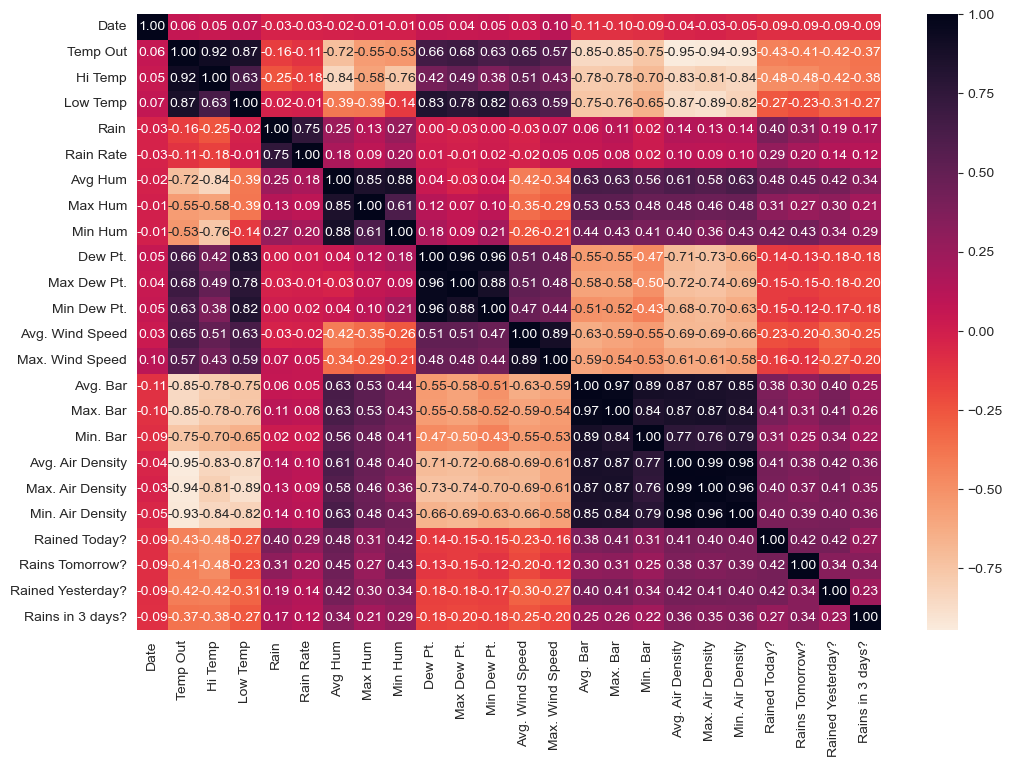

In [34]:
plt.figure(figsize=(12, 8))
sns.heatmap(new_data.corr(), cmap="rocket_r", annot=True, fmt=".2f")

### Some visualizations

Text(0, 0.5, 'Average Bar (hPa)')

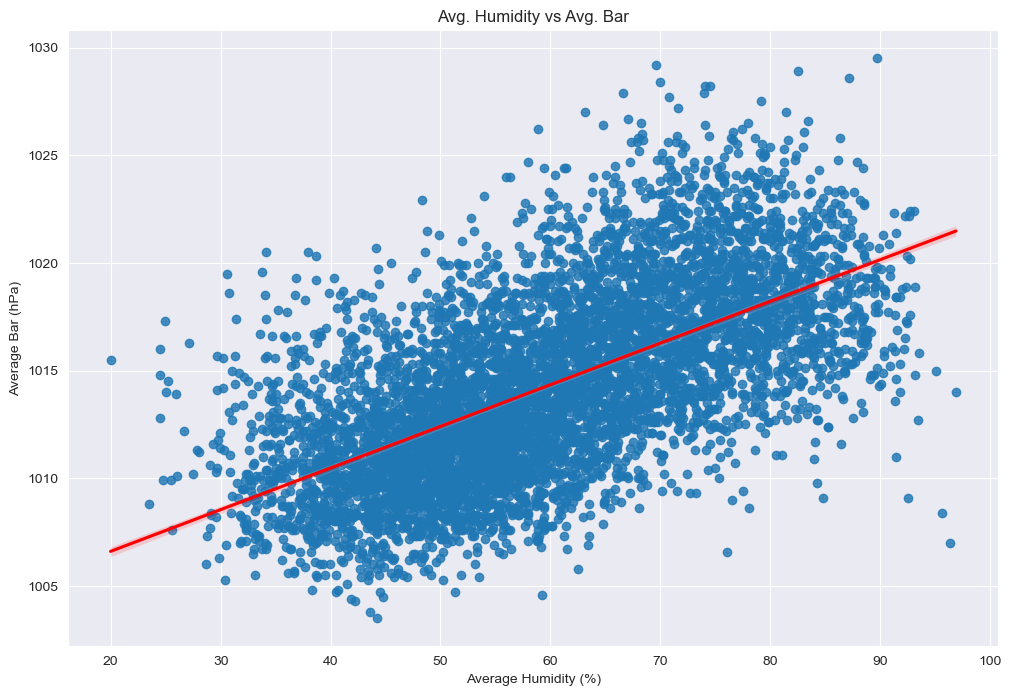

In [35]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x=new_data["Avg Hum"], y=new_data["Avg. Bar"], alpha=0.5, marker="+")
sns.regplot(x=new_data["Avg Hum"], y=new_data["Avg. Bar"], line_kws={"color": "red"})

plt.title("Avg. Humidity vs Avg. Bar")
plt.xlabel("Average Humidity (%)")
plt.ylabel("Average Bar (hPa)")

Text(0, 0.5, 'Average Air Density')

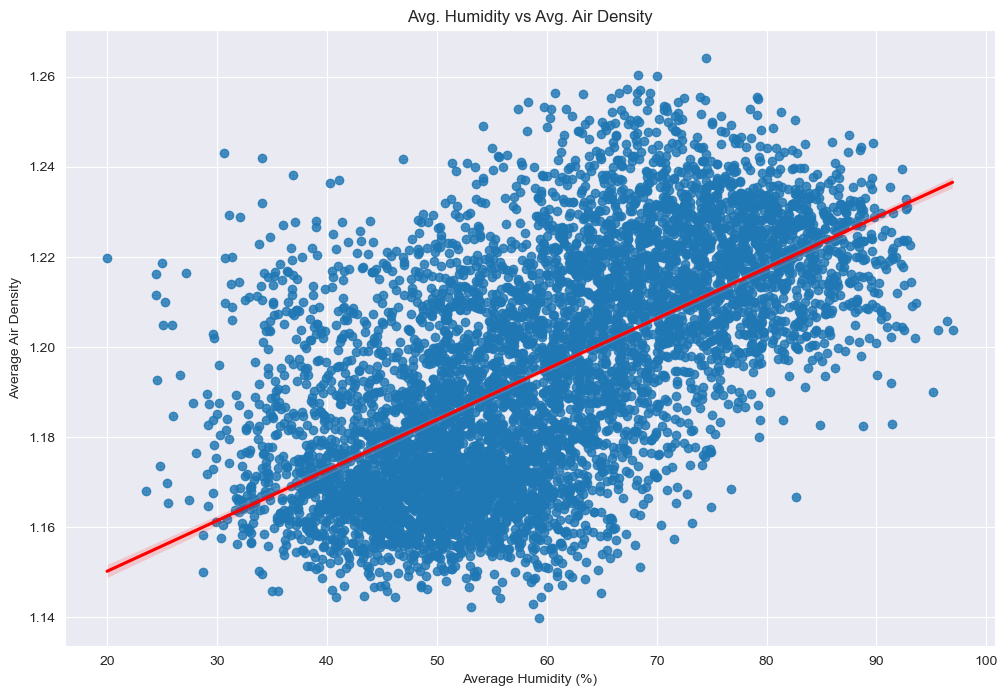

In [36]:
plt.figure(figsize=(12, 8))

sns.scatterplot(x=new_data["Avg Hum"], y=new_data["Avg. Air Density"], alpha=0.5, marker="+")
sns.regplot(x=new_data["Avg Hum"], y=new_data["Avg. Air Density"], line_kws={"color": "red"})

plt.title("Avg. Humidity vs Avg. Air Density")
plt.xlabel("Average Humidity (%)")
plt.ylabel("Average Air Density")

### Logistic Regression

In [37]:
headers_new_model_data = ["Rain","Rain Rate",
                          "Avg Hum", "Max Hum", "Min Hum",
                          "Avg. Bar", "Max. Bar", "Min. Bar",
                          "Avg. Air Density", "Max. Air Density", "Min. Air Density",
                          "Rained Today?", "Rained Yesterday?", "Rains Tomorrow?"]
model_data = new_data[headers_new_model_data]
model_data

,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rained Yesterday?,Rains Tomorrow?
0,0.0,0.0,34.99,52,19,1007.9,1010.0,1006.6,1.1459,1.1582,1.1370,0,0.0,0.0
1,0.0,0.0,51.37,78,30,1010.4,1012.4,1007.8,1.1591,1.1720,1.1392,0,0.0,0.0
2,0.0,0.0,49.89,81,30,1012.7,1014.8,1011.4,1.1668,1.1772,1.1561,0,0.0,0.0
3,0.0,0.0,54.95,73,14,1012.5,1014.9,1005.8,1.1709,1.1777,1.1492,0,0.0,0.0
4,0.0,0.0,36.17,57,22,1007.8,1009.9,1006.3,1.1621,1.1727,1.1491,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,0.0,0.0,33.24,64,12,1009.1,1010.8,1007.2,1.1665,1.1787,1.1535,0,0.0,0.0
6248,0.0,0.0,33.05,62,10,1009.0,1010.2,1007.4,1.1690,1.1806,1.1570,0,0.0,0.0
6249,0.0,0.0,39.77,62,17,1008.7,1010.4,1007.5,1.1691,1.1755,1.1599,0,0.0,0.0
6250,0.0,0.0,35.27,65,15,1007.9,1010.1,1005.6,1.1689,1.1815,1.1558,0,0.0,0.0


#### No downsampling or oversampling

##### Separate in features and labels

In [38]:
x_unb = model_data.drop(columns="Rains Tomorrow?")
y_unb = model_data["Rains Tomorrow?"]

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

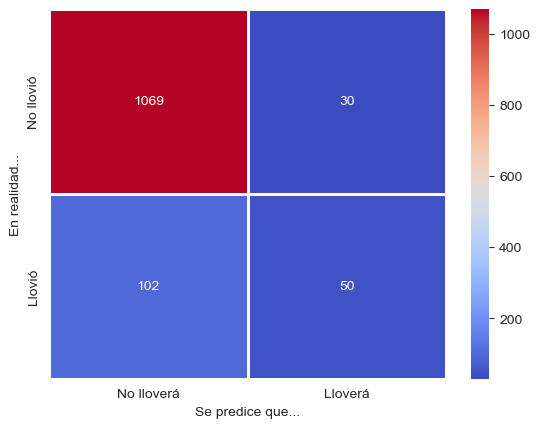

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

x_train, x_test, y_train, y_test = train_test_split(x_unb, y_unb, test_size=0.2, random_state=42)

# Model
logReg = LogisticRegression(max_iter=2048, random_state=42)
logReg.fit(x_train, y_train)
predictions= logReg.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [40]:
logReg.score(x_test, y_test)

0.894484412470024

In [41]:
print(classification_report(y_test, predictions, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9129    0.9727    0.9419      1099
        Rain     0.6250    0.3289    0.4310       152

    accuracy                         0.8945      1251
   macro avg     0.7689    0.6508    0.6864      1251
weighted avg     0.8779    0.8945    0.8798      1251



In [42]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(logReg, x_unb, y_unb, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

Accuracy promedio: 0.8952


##### ROC Curve

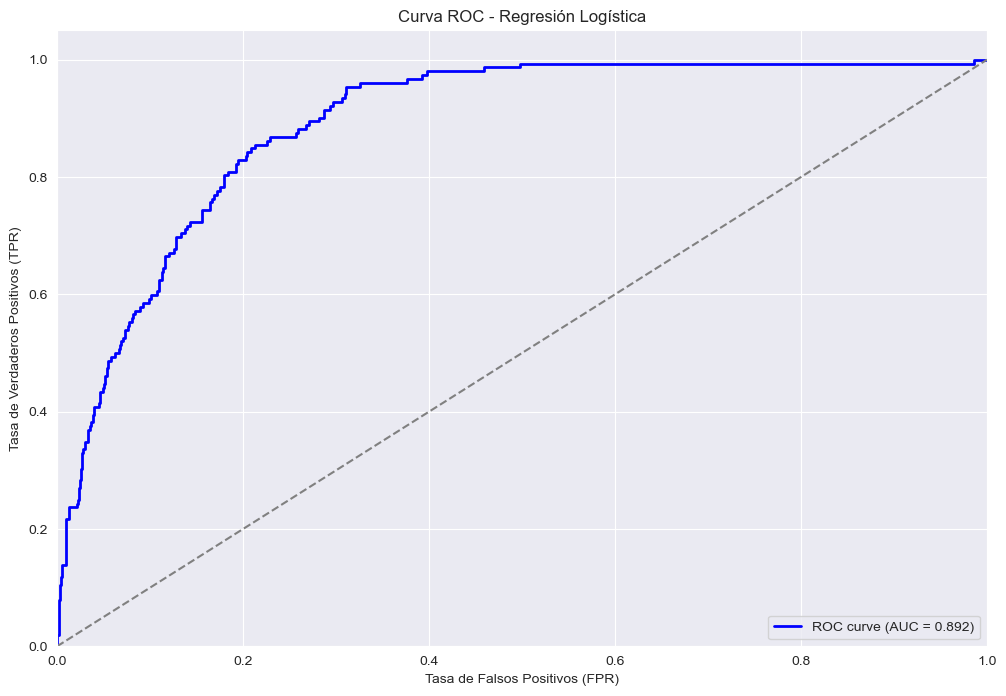

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener probabilidades en vez de predicciones binarias
y_probs = logReg.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.show()

#### Downsampling the majority

In [44]:
model_data["Rains Tomorrow?"].value_counts()

Rains Tomorrow?
0.0    5459
1.0     793
Name: count, dtype: int64

In [45]:
from sklearn.utils import resample
majority = model_data[model_data["Rains Tomorrow?"] == 0]
minority = model_data[model_data["Rains Tomorrow?"] == 1]
model_data_majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)
model_data_majority_downsampled.shape

(793, 14)

In [46]:
model_data_downsampled = pd.concat([model_data_majority_downsampled, minority])
model_data_downsampled = model_data_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)
model_data_downsampled

,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rained Yesterday?,Rains Tomorrow?
0,0.00,0.0,32.91,60,10,1009.2,1010.7,1007.3,1.1658,1.1785,1.1507,0,0.0,0.0
1,0.00,0.0,78.47,92,54,1021.9,1024.1,1019.8,1.2392,1.2443,1.2345,0,0.0,0.0
2,0.25,0.0,69.27,85,36,1023.2,1025.1,1021.2,1.2546,1.2713,1.2437,1,0.0,1.0
3,0.20,0.0,80.30,89,62,1018.7,1024.6,1015.5,1.2394,1.2456,1.2323,1,1.0,0.0
4,0.00,0.0,50.89,78,22,1011.1,1013.1,1008.7,1.1874,1.1969,1.1783,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1581,11.62,0.7,85.15,93,66,1021.1,1023.2,1018.2,1.2300,1.2353,1.2271,1,1.0,1.0
1582,0.00,0.0,64.07,88,38,1012.8,1014.6,1011.3,1.1913,1.1961,1.1847,0,0.0,1.0
1583,0.00,0.0,73.72,93,49,1013.8,1015.9,1012.1,1.1974,1.2055,1.1905,0,0.0,1.0
1584,7.40,0.5,92.38,94,90,1018.9,1021.8,1017.4,1.2177,1.2250,1.1929,1,1.0,1.0


##### Separate in features and labels

In [47]:
x = model_data_downsampled.drop(columns="Rains Tomorrow?")
y = model_data_downsampled["Rains Tomorrow?"]

##### Model creation and fitting

C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0.5, 25.52222222222222, 'Se predice que...')

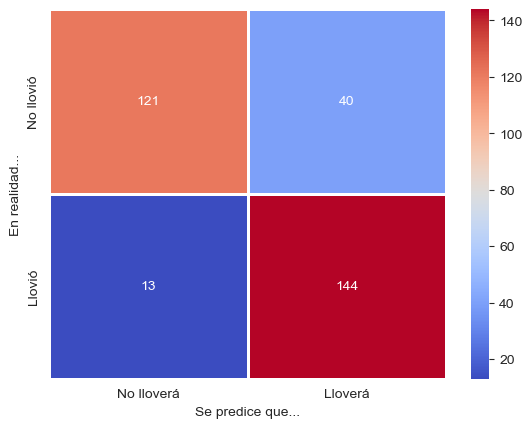

In [48]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Model
logReg = LogisticRegression(max_iter=2048, random_state=42)
logReg.fit(x_train, y_train)
predictions= logReg.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [49]:
logReg.score(x_test, y_test)

0.8333333333333334

In [50]:
print(classification_report(y_test, predictions, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9030    0.7516    0.8203       161
        Rain     0.7826    0.9172    0.8446       157

    accuracy                         0.8333       318
   macro avg     0.8428    0.8344    0.8325       318
weighted avg     0.8436    0.8333    0.8323       318



In [51]:
scores = cross_val_score(logReg, x, y, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

Accuracy promedio: 0.8266


C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

##### ROC Curve

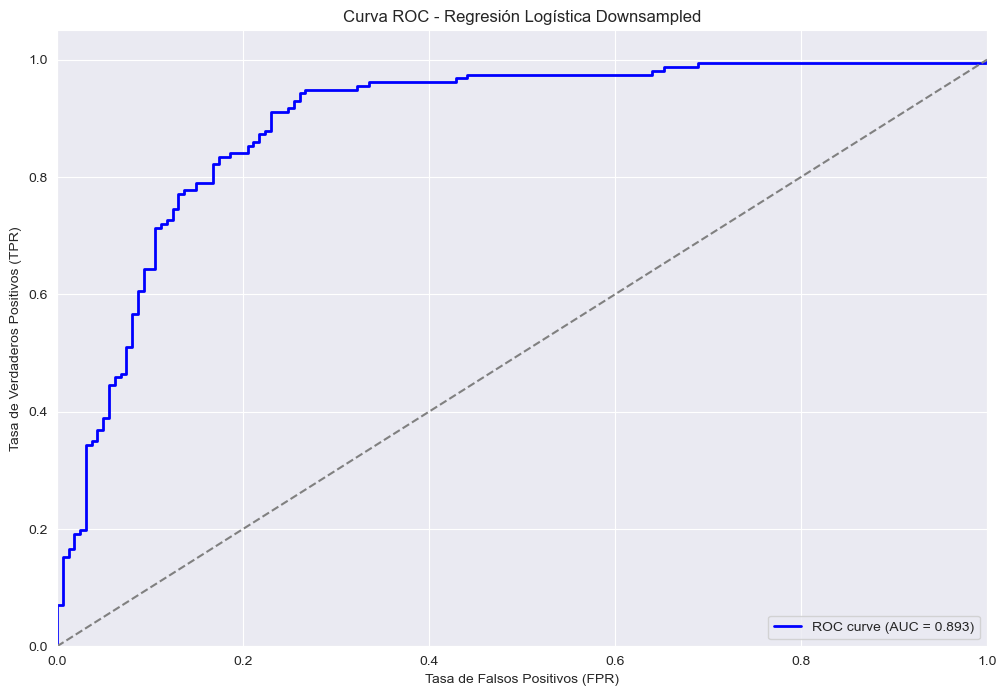

In [52]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = logReg.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística Downsampled')
plt.legend(loc='lower right')
plt.show()

##### Obtaining new data to predict according to model

In [53]:
cols_to_use = ["Date","Rain","Rain Rate","Out Hum","Bar","In Air Density"]
cols_no_date = ["Rain","Rain Rate","Out Hum","Bar","In Air Density"]

input_data = pd.read_csv("may25.csv", sep=";")[cols_to_use]
input_data["Date"] = pd.to_datetime(input_data["Date"], format="%d-%m-%y")
input_data

,Date,Rain,Rain Rate,Out Hum,Bar,In Air Density
0,2025-05-01,0.0,0.0,72,1016.4,1.2126
1,2025-05-01,0.0,0.0,72,1016.5,1.2130
2,2025-05-01,0.0,0.0,73,1016.4,1.2125
3,2025-05-01,0.0,0.0,72,1016.4,1.2126
4,2025-05-01,0.0,0.0,72,1016.5,1.2129
...,...,...,...,...,...,...
2546,2025-05-27,0.0,0.0,80,1022.6,1.2360
2547,2025-05-27,0.0,0.0,80,1022.7,1.2359
2548,2025-05-27,0.0,0.0,81,1023.0,1.2360
2549,2025-05-27,0.0,0.0,82,1023.3,1.2363


In [54]:
# ["Rain","Rain Rate", "Avg Hum", "Max Hum", "Min Hum", "Avg. Bar", "Max. Bar", "Min. Bar", "Avg. Air Density", "Max. Air Density", "Min. Air Density", "Rained Today?", "Rained Yesterday?", "Rains Tomorrow?"]
rain_input = input_data.groupby("Date")["Rain"].sum().round(2)
rain_rate_input = input_data.groupby("Date")["Rain Rate"].sum().round(2)

max_hum_input = input_data.groupby("Date")["Out Hum"].max().rename("Max Hum")
min_hum_input = input_data.groupby("Date")["Out Hum"].min().rename("Min Hum")
avg_hum_input = input_data.groupby("Date")["Out Hum"].mean().rename("Avg Hum").round(2)

avg_bar_input = input_data.groupby("Date")["Bar"].mean().rename("Avg. Bar").round(1)
max_bar_input = input_data.groupby("Date")["Bar"].max().rename("Max. Bar")
min_bar_input = input_data.groupby("Date")["Bar"].min().rename("Min. Bar")

avg_air_density_input = input_data.groupby("Date")["In Air Density"].mean().rename("Avg. Air Density").round(4)
max_air_density_input = input_data.groupby("Date")["In Air Density"].max().rename("Max. Air Density")
min_air_density_input = input_data.groupby("Date")["In Air Density"].min().rename("Min. Air Density")

pre_data_to_predict = pd.concat([rain_input, rain_rate_input,
                                 avg_hum_input, max_hum_input, min_hum_input,
                                 avg_bar_input, max_bar_input, min_bar_input,
                                 avg_air_density_input, max_air_density_input, min_air_density_input], axis=1).reset_index()
data_to_predict = pre_data_to_predict.drop(columns=["Date"])
data_to_predict

,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density
0,0.0,0.0,60.87,76,35,1017.6,1019.0,1016.1,1.2138,1.2180,1.2095
1,0.0,0.0,52.19,84,19,1017.0,1018.9,1014.8,1.2153,1.2252,1.2039
2,0.0,0.0,41.28,76,12,1014.0,1015.6,1011.8,1.2117,1.2195,1.2019
3,0.0,0.0,40.28,74,13,1014.6,1015.7,1012.5,1.2108,1.2199,1.2018
4,0.0,0.0,48.09,76,21,1013.4,1015.1,1011.4,1.2075,1.2165,1.1982
5,0.0,0.0,69.36,83,56,1015.5,1016.8,1014.2,1.2108,1.2157,1.2046
6,0.0,0.0,64.81,83,33,1014.0,1015.6,1013.0,1.2118,1.2150,1.2080
7,16.0,145.4,86.32,89,75,1016.9,1021.9,1012.5,1.2177,1.2253,1.2117
8,0.2,0.0,73.20,90,37,1020.4,1022.7,1017.6,1.2236,1.2319,1.2138
9,0.0,0.0,58.60,89,13,1012.6,1017.3,1008.7,1.2085,1.2208,1.1881


In [55]:
data_to_predict["Rained Today?"] = (data_to_predict["Rain"] > 0).astype(int)
data_to_predict["Rained Yesterday?"] = data_to_predict["Rained Today?"].shift(1)
data_to_predict = data_to_predict.fillna(0)
data_to_predict

,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rained Yesterday?
0,0.0,0.0,60.87,76,35,1017.6,1019.0,1016.1,1.2138,1.2180,1.2095,0,0.0
1,0.0,0.0,52.19,84,19,1017.0,1018.9,1014.8,1.2153,1.2252,1.2039,0,0.0
2,0.0,0.0,41.28,76,12,1014.0,1015.6,1011.8,1.2117,1.2195,1.2019,0,0.0
3,0.0,0.0,40.28,74,13,1014.6,1015.7,1012.5,1.2108,1.2199,1.2018,0,0.0
4,0.0,0.0,48.09,76,21,1013.4,1015.1,1011.4,1.2075,1.2165,1.1982,0,0.0
5,0.0,0.0,69.36,83,56,1015.5,1016.8,1014.2,1.2108,1.2157,1.2046,0,0.0
6,0.0,0.0,64.81,83,33,1014.0,1015.6,1013.0,1.2118,1.2150,1.2080,0,0.0
7,16.0,145.4,86.32,89,75,1016.9,1021.9,1012.5,1.2177,1.2253,1.2117,1,0.0
8,0.2,0.0,73.20,90,37,1020.4,1022.7,1017.6,1.2236,1.2319,1.2138,1,1.0
9,0.0,0.0,58.60,89,13,1012.6,1017.3,1008.7,1.2085,1.2208,1.1881,0,1.0


##### Predictions on new data

In [56]:
prediction_input_data = logReg.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,Yes
1,No
2,No
3,No
4,No
5,No
6,Yes
7,No
8,Yes
9,No


In [57]:
y_probs_lluvia = logReg.predict_proba(data_to_predict)[:, 1]
for i in range(0, len(y_probs_lluvia)):
    print(f"Probabilidad que llueva mañana, {i+2}/05: {y_probs_lluvia[i].round(3)*100:.2f}%")

Probabilidad que llueva mañana, 2/05: 54.30%
Probabilidad que llueva mañana, 3/05: 7.90%
Probabilidad que llueva mañana, 4/05: 2.20%
Probabilidad que llueva mañana, 5/05: 2.00%
Probabilidad que llueva mañana, 6/05: 7.60%
Probabilidad que llueva mañana, 7/05: 38.70%
Probabilidad que llueva mañana, 8/05: 58.70%
Probabilidad que llueva mañana, 9/05: 0.00%
Probabilidad que llueva mañana, 10/05: 87.10%
Probabilidad que llueva mañana, 11/05: 47.50%
Probabilidad que llueva mañana, 12/05: 48.20%
Probabilidad que llueva mañana, 13/05: 71.50%
Probabilidad que llueva mañana, 14/05: 67.80%
Probabilidad que llueva mañana, 15/05: 58.10%
Probabilidad que llueva mañana, 16/05: 29.30%
Probabilidad que llueva mañana, 17/05: 61.00%
Probabilidad que llueva mañana, 18/05: 90.30%
Probabilidad que llueva mañana, 19/05: 6.80%
Probabilidad que llueva mañana, 20/05: 13.20%
Probabilidad que llueva mañana, 21/05: 86.80%
Probabilidad que llueva mañana, 22/05: 77.70%
Probabilidad que llueva mañana, 23/05: 78.10%
Pr

#### Oversampling the minority

In [58]:
majority = model_data[model_data["Rains Tomorrow?"] == 0]
minority = model_data[model_data["Rains Tomorrow?"] == 1]
model_data_minority_oversampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
model_data_minority_oversampled.shape

(5459, 14)

In [59]:
model_data_oversampled = pd.concat([majority, model_data_minority_oversampled])
model_data_oversampled = model_data_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)
model_data_oversampled

,Rain,Rain Rate,Avg Hum,Max Hum,Min Hum,Avg. Bar,Max. Bar,Min. Bar,Avg. Air Density,Max. Air Density,Min. Air Density,Rained Today?,Rained Yesterday?,Rains Tomorrow?
0,13.66,0.7,75.85,84,40,1015.0,1019.8,1012.4,1.2318,1.2359,1.2263,1,0.0,1.0
1,0.00,0.0,82.71,97,61,1021.3,1023.5,1017.7,1.2313,1.2380,1.2230,0,1.0,1.0
2,34.24,2.0,72.48,83,50,1010.2,1015.0,1006.4,1.1999,1.2084,1.1942,1,1.0,1.0
3,0.00,0.0,64.89,91,36,1013.5,1017.0,1011.9,1.2057,1.2124,1.1955,0,0.0,0.0
4,0.00,0.0,51.52,80,30,1010.2,1011.7,1009.0,1.1534,1.1654,1.1430,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10913,0.00,0.0,74.81,94,39,1020.1,1021.3,1018.4,1.2226,1.2320,1.1949,0,0.0,1.0
10914,0.00,0.0,67.45,85,46,1013.6,1016.3,1011.4,1.2105,1.2156,1.2039,0,0.0,0.0
10915,0.00,0.0,42.81,74,17,1010.6,1013.3,1007.9,1.1729,1.1876,1.1582,0,0.0,0.0
10916,0.00,0.0,45.38,75,25,1011.5,1012.8,1009.9,1.1756,1.1859,1.1609,0,0.0,0.0


##### Separate in features and labels

In [60]:
x2 = model_data_oversampled.drop(columns="Rains Tomorrow?")
y2 = model_data_oversampled["Rains Tomorrow?"]

##### Model creation and fitting

C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Text(0.5, 25.52222222222222, 'Se predice que...')

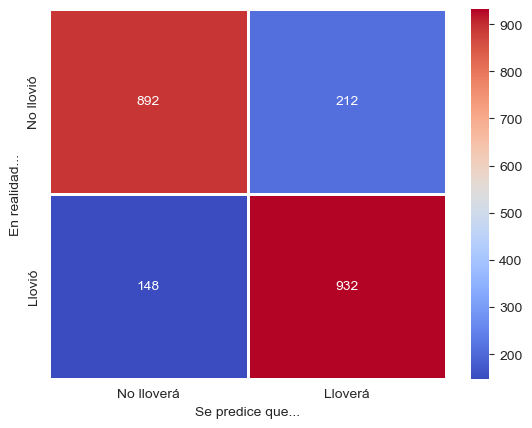

In [61]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2, random_state=42)

# Model
logReg2 = LogisticRegression(max_iter=2048, random_state=42)
logReg2.fit(x_train2, y_train2)
predictions2 = logReg2.predict(x_test2)

# Confusion Matrix
cm2 = confusion_matrix(y_test2, predictions2)
sns.heatmap(cm2, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [62]:
logReg2.score(x_test2, y_test2)

0.8351648351648352

In [63]:
print(classification_report(y_test2, predictions2, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.8577    0.8080    0.8321      1104
        Rain     0.8147    0.8630    0.8381      1080

    accuracy                         0.8352      2184
   macro avg     0.8362    0.8355    0.8351      2184
weighted avg     0.8364    0.8352    0.8351      2184



In [64]:
scores = cross_val_score(logReg2, x2, y2, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logisti

Accuracy promedio: 0.8370


C:\Users\Benjamín Herrera\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### ROC Curve

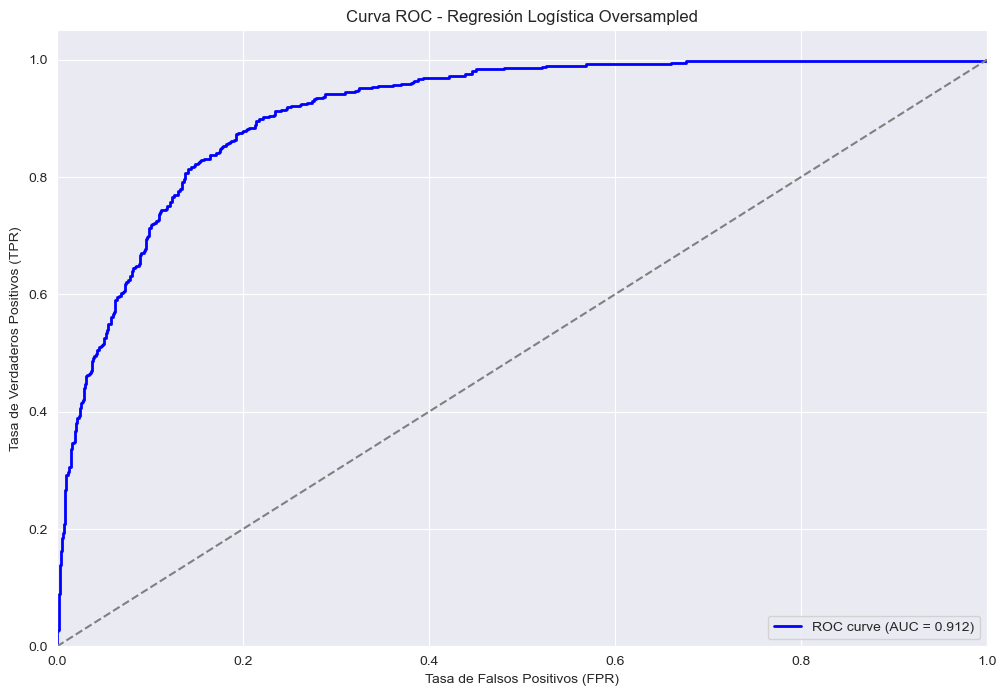

In [65]:
# Obtener probabilidades en vez de predicciones binarias
y_probs2 = logReg2.predict_proba(x_test2)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr2, tpr2, thresholds2 = roc_curve(y_test2, y_probs2)
roc_auc2 = auc(fpr2, tpr2)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr2, tpr2, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc2:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística Oversampled')
plt.legend(loc='lower right')

##### Predictions on new data

In [66]:
prediction_input_data = logReg2.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,Yes
7,No
8,Yes
9,No


In [67]:
y_probs_lluvia = logReg2.predict_proba(data_to_predict)[:, 1]
for i in range(0, len(y_probs_lluvia)):
    print(f"Probabilidad que llueva mañana, {i+2}/05: {y_probs_lluvia[i].round(3)*100:.2f}%")

Probabilidad que llueva mañana, 2/05: 49.30%
Probabilidad que llueva mañana, 3/05: 8.30%
Probabilidad que llueva mañana, 4/05: 2.70%
Probabilidad que llueva mañana, 5/05: 2.40%
Probabilidad que llueva mañana, 6/05: 8.20%
Probabilidad que llueva mañana, 7/05: 41.90%
Probabilidad que llueva mañana, 8/05: 53.00%
Probabilidad que llueva mañana, 9/05: 0.00%
Probabilidad que llueva mañana, 10/05: 85.10%
Probabilidad que llueva mañana, 11/05: 41.30%
Probabilidad que llueva mañana, 12/05: 44.10%
Probabilidad que llueva mañana, 13/05: 65.00%
Probabilidad que llueva mañana, 14/05: 67.70%
Probabilidad que llueva mañana, 15/05: 50.80%
Probabilidad que llueva mañana, 16/05: 27.80%
Probabilidad que llueva mañana, 17/05: 58.80%
Probabilidad que llueva mañana, 18/05: 88.80%
Probabilidad que llueva mañana, 19/05: 12.80%
Probabilidad que llueva mañana, 20/05: 21.90%
Probabilidad que llueva mañana, 21/05: 83.60%
Probabilidad que llueva mañana, 22/05: 76.30%
Probabilidad que llueva mañana, 23/05: 71.10%
P

#### SMOTE

##### Sampling with SMOTE

In [68]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(x_unb, y_unb)

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

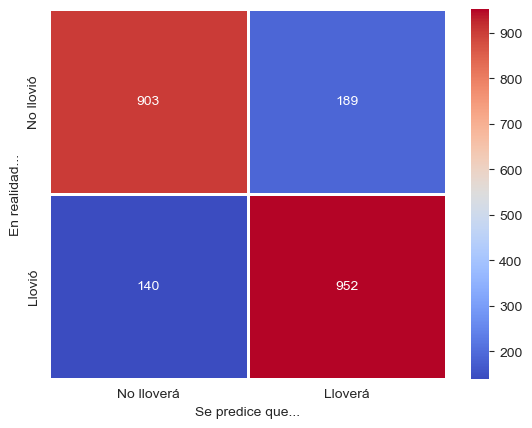

In [69]:
x_train, x_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Model
logReg = LogisticRegression(random_state=42, max_iter=16384)
logReg.fit(x_train, y_train)
predictions = logReg.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [70]:
logReg.score(x_test, y_test)

0.8493589743589743

In [71]:
print(classification_report(y_test, predictions, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.8658    0.8269    0.8459      1092
        Rain     0.8344    0.8718    0.8527      1092

    accuracy                         0.8494      2184
   macro avg     0.8501    0.8494    0.8493      2184
weighted avg     0.8501    0.8494    0.8493      2184



In [72]:
scores = cross_val_score(logReg, X_resampled, y_resampled, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.8415


##### ROC Curve

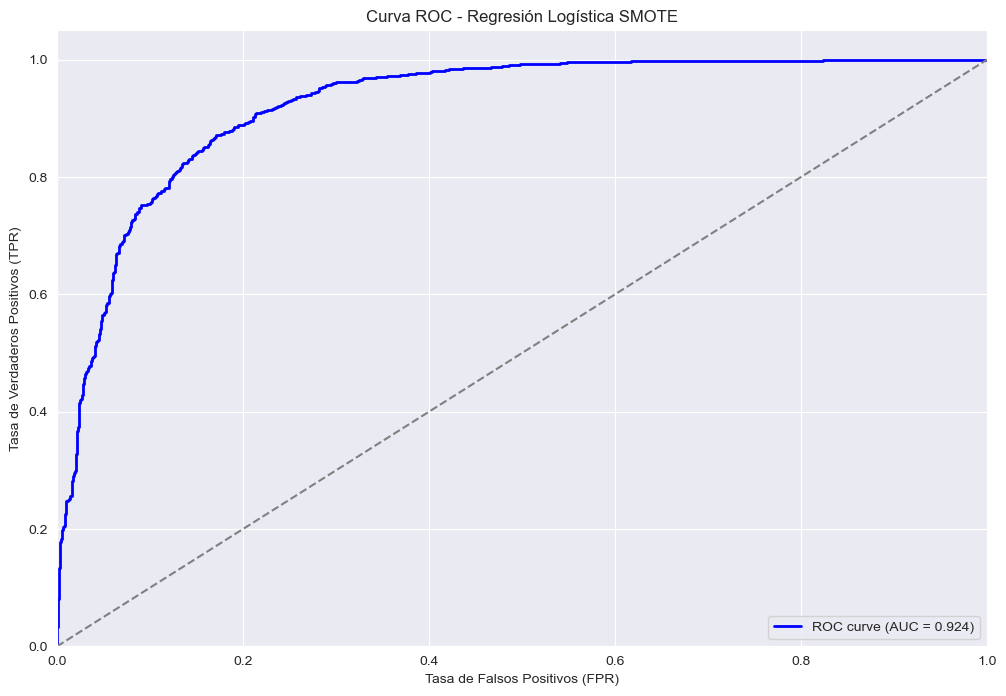

In [73]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = logReg.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística SMOTE')
plt.legend(loc='lower right')

##### Predictions on new data

In [74]:
prediction_input_data = logReg.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,Yes
1,No
2,No
3,No
4,No
5,No
6,Yes
7,No
8,Yes
9,No


In [75]:
y_probs_lluvia = logReg.predict_proba(data_to_predict)[:, 1]
for i in range(0, len(y_probs_lluvia)):
    print(f"Probabilidad que llueva mañana, {i+2}/05: {y_probs_lluvia[i].round(3)*100:.2f}%")

Probabilidad que llueva mañana, 2/05: 58.00%
Probabilidad que llueva mañana, 3/05: 6.50%
Probabilidad que llueva mañana, 4/05: 1.80%
Probabilidad que llueva mañana, 5/05: 1.60%
Probabilidad que llueva mañana, 6/05: 6.90%
Probabilidad que llueva mañana, 7/05: 39.90%
Probabilidad que llueva mañana, 8/05: 60.40%
Probabilidad que llueva mañana, 9/05: 0.00%
Probabilidad que llueva mañana, 10/05: 73.80%
Probabilidad que llueva mañana, 11/05: 47.70%
Probabilidad que llueva mañana, 12/05: 48.90%
Probabilidad que llueva mañana, 13/05: 72.70%
Probabilidad que llueva mañana, 14/05: 43.40%
Probabilidad que llueva mañana, 15/05: 59.50%
Probabilidad que llueva mañana, 16/05: 29.20%
Probabilidad que llueva mañana, 17/05: 63.00%
Probabilidad que llueva mañana, 18/05: 93.00%
Probabilidad que llueva mañana, 19/05: 0.00%
Probabilidad que llueva mañana, 20/05: 0.00%
Probabilidad que llueva mañana, 21/05: 89.10%
Probabilidad que llueva mañana, 22/05: 55.80%
Probabilidad que llueva mañana, 23/05: 79.70%
Pro

### Gaussian Naive Bayes

Text(0.5, 25.52222222222222, 'Se predice que...')

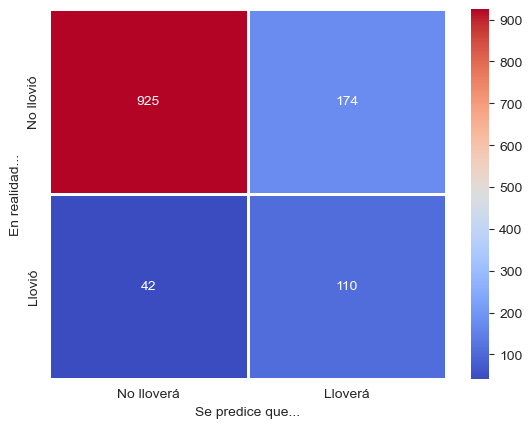

In [76]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
x_train, x_test, y_train, y_test = train_test_split(x_unb, y_unb, test_size=0.2, random_state=42)
gnb.fit(x_train, y_train)
y_pred = gnb.predict(x_test)

# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [77]:
gnb.score(x_test, y_test)

0.8273381294964028

In [78]:
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9566    0.8417    0.8955      1099
        Rain     0.3873    0.7237    0.5046       152

    accuracy                         0.8273      1251
   macro avg     0.6719    0.7827    0.7000      1251
weighted avg     0.8874    0.8273    0.8480      1251



In [79]:
scores = cross_val_score(gnb, x_unb, y_unb, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.8295


##### ROC Curve

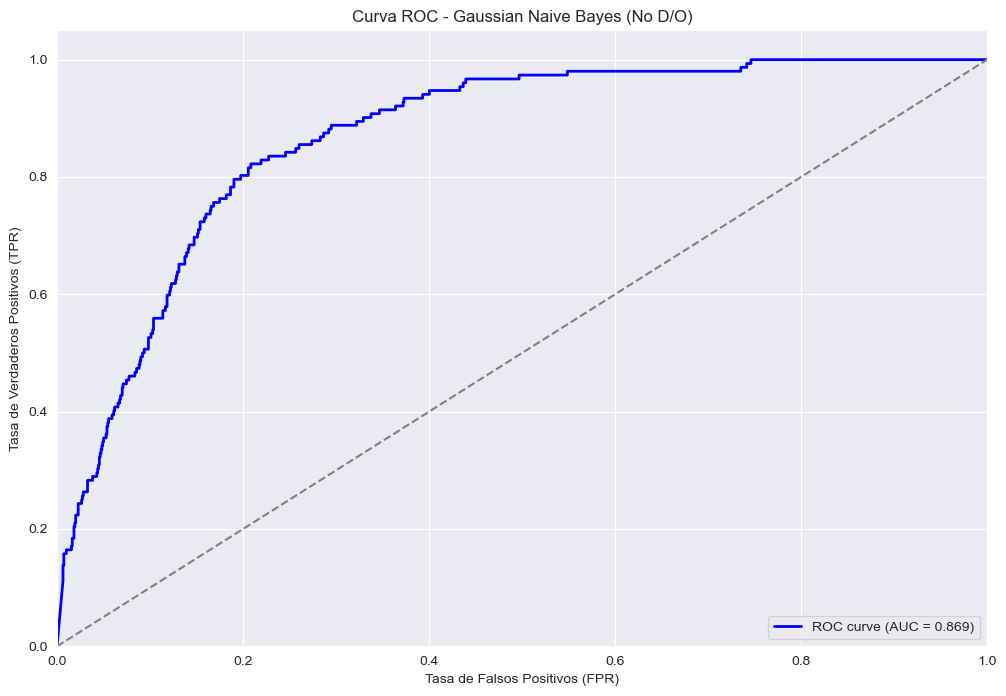

In [80]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = gnb.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Gaussian Naive Bayes (No D/O)')
plt.legend(loc='lower right')

##### Predictions on new data

In [81]:
prediction_input_data = gnb.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,No
7,Yes
8,Yes
9,No


#### Downsampling the majority

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

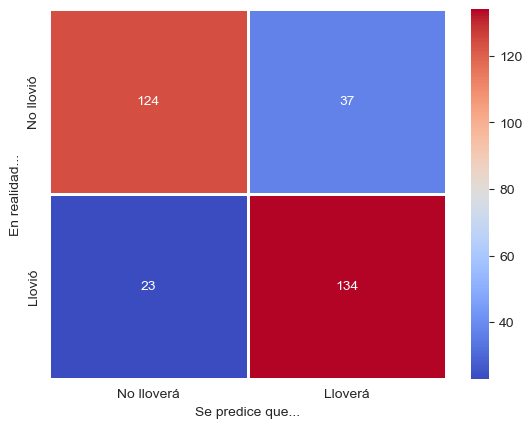

In [82]:
gnb = GaussianNB()
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
gnb.fit(x_train, y_train)
y_pred = gnb.predict(x_test)

# Confusion Matrix
cm_gnb = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [83]:
gnb.score(x_test, y_test)

0.8113207547169812

In [84]:
print(classification_report(y_test, y_pred, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.8435    0.7702    0.8052       161
        Rain     0.7836    0.8535    0.8171       157

    accuracy                         0.8113       318
   macro avg     0.8136    0.8118    0.8111       318
weighted avg     0.8140    0.8113    0.8111       318



In [85]:
scores = cross_val_score(gnb, x, y, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.7995


##### ROC Curve

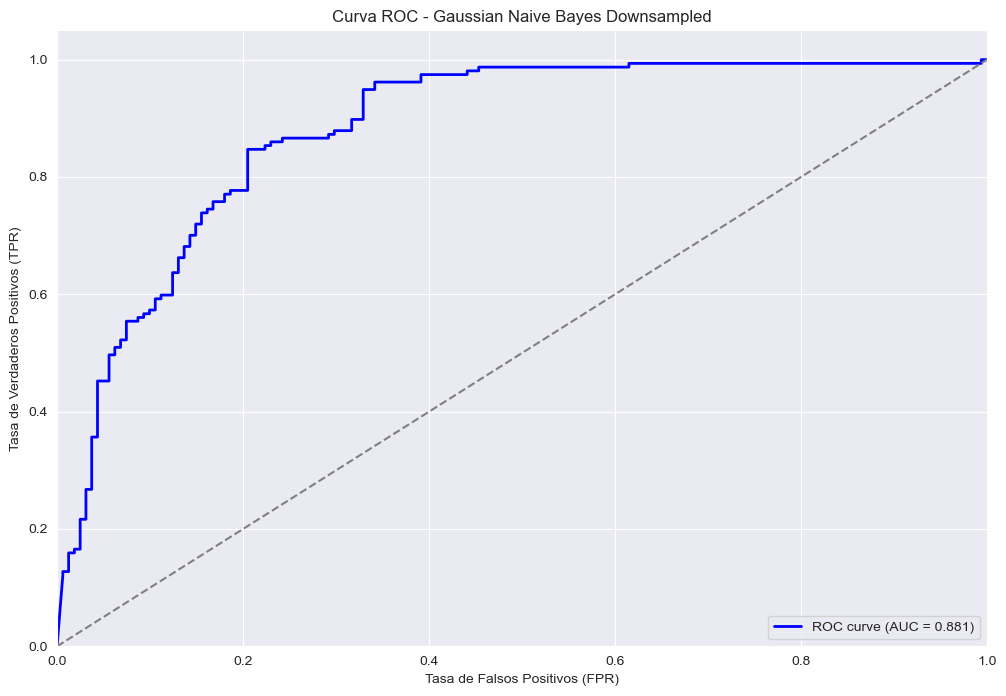

In [86]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = gnb.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Gaussian Naive Bayes Downsampled')
plt.legend(loc='lower right')

##### Predictions on new data

In [87]:
prediction_input_data = gnb.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,No
7,Yes
8,Yes
9,No


#### Oversampling the majority

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

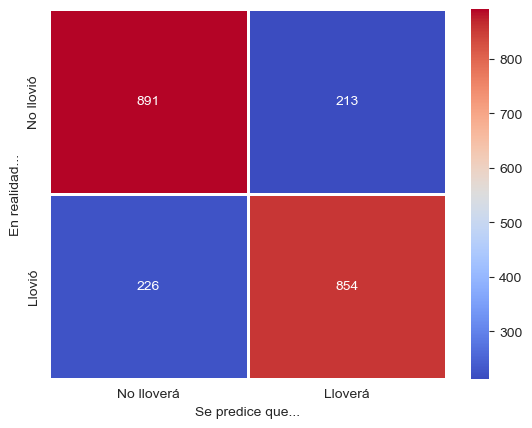

In [88]:
gnb2 = GaussianNB()
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2, random_state=42)
gnb2.fit(x_train2, y_train2)
y_pred2 = gnb2.predict(x_test2)

# Confusion Matrix
cm_gnb = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm_gnb, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [89]:
gnb2.score(x_test, y_test)

0.8113207547169812

In [90]:
print(classification_report(y_test2, y_pred2, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.7977    0.8071    0.8023      1104
        Rain     0.8004    0.7907    0.7955      1080

    accuracy                         0.7990      2184
   macro avg     0.7990    0.7989    0.7989      2184
weighted avg     0.7990    0.7990    0.7990      2184



In [91]:
scores = cross_val_score(gnb2, x2, y2, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.8031


##### ROC Curve

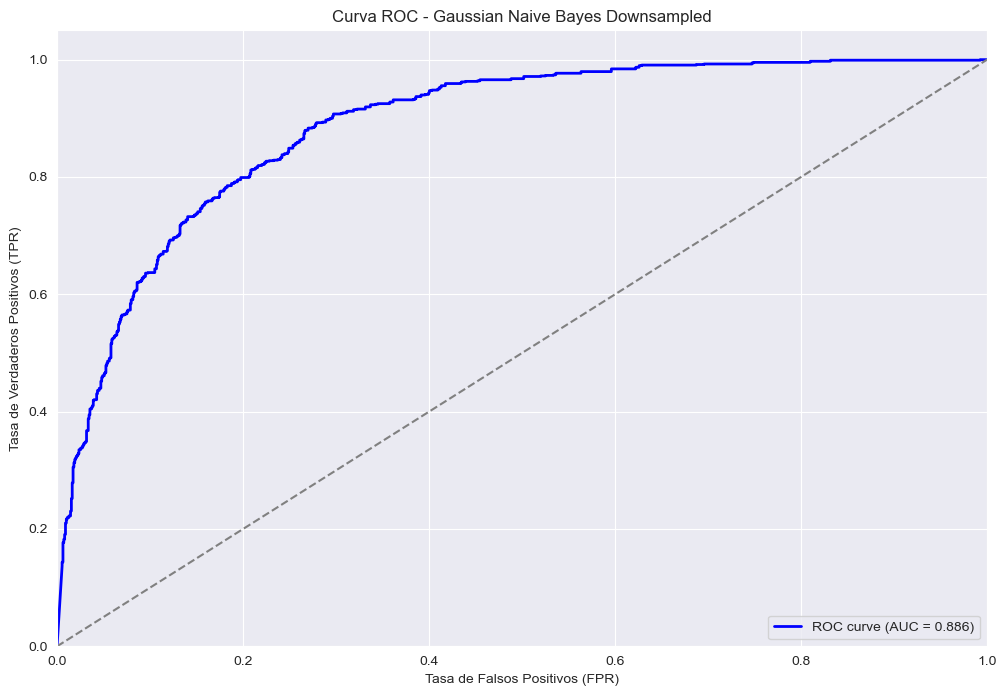

In [92]:
# Obtener probabilidades en vez de predicciones binarias
y_probs2 = gnb.predict_proba(x_test2)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr2, tpr2, thresholds2 = roc_curve(y_test2, y_probs2)
roc_auc2 = auc(fpr2, tpr2)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr2, tpr2, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc2:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Gaussian Naive Bayes Downsampled')
plt.legend(loc='lower right')

##### Predictions on new data

In [93]:
prediction_input_data = gnb2.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,No
7,Yes
8,Yes
9,No


### Random Forest

#### No downsampling or oversampling

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

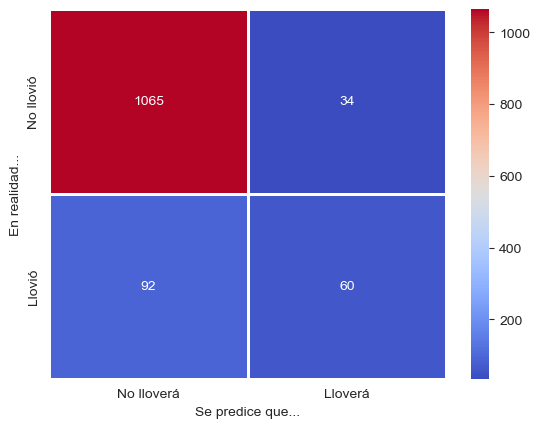

In [94]:
from sklearn.ensemble import RandomForestClassifier

x_train, x_test, y_train, y_test = train_test_split(x_unb, y_unb, test_size=0.2, random_state=42)

# Model
randomForest = RandomForestClassifier(random_state=42)
randomForest.fit(x_train, y_train)
predictions_rf = randomForest.predict(x_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, predictions_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [95]:
randomForest.score(x_test, y_test)

0.8992805755395683

In [96]:
print(classification_report(y_test, predictions_rf, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9205    0.9691    0.9441      1099
        Rain     0.6383    0.3947    0.4878       152

    accuracy                         0.8993      1251
   macro avg     0.7794    0.6819    0.7160      1251
weighted avg     0.8862    0.8993    0.8887      1251



In [97]:
scores = cross_val_score(randomForest, x_unb, y_unb, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.8808


##### ROC Curve

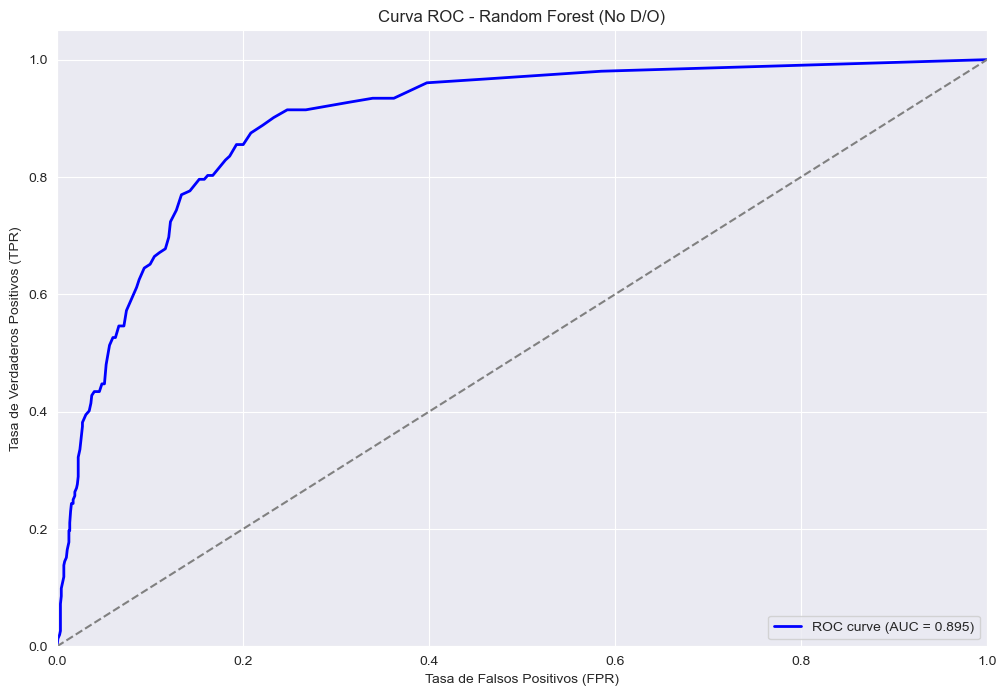

In [98]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = randomForest.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest (No D/O)')
plt.legend(loc='lower right')

#### Downsampling the majority

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

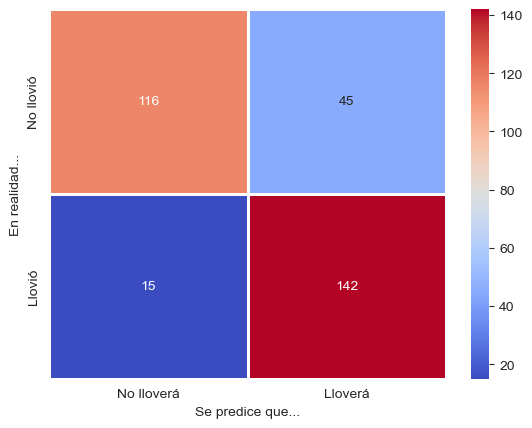

In [99]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Model
randomForest = RandomForestClassifier(random_state=42)
randomForest.fit(x_train, y_train)
predictions_rf = randomForest.predict(x_test)

# Confusion Matrix
cm_rf = confusion_matrix(y_test, predictions_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [100]:
randomForest.score(x_test, y_test)

0.8113207547169812

In [101]:
print(classification_report(y_test, predictions_rf, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.8855    0.7205    0.7945       161
        Rain     0.7594    0.9045    0.8256       157

    accuracy                         0.8113       318
   macro avg     0.8224    0.8125    0.8101       318
weighted avg     0.8232    0.8113    0.8099       318



In [102]:
scores = cross_val_score(randomForest, x, y, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.8260


##### ROC Curve

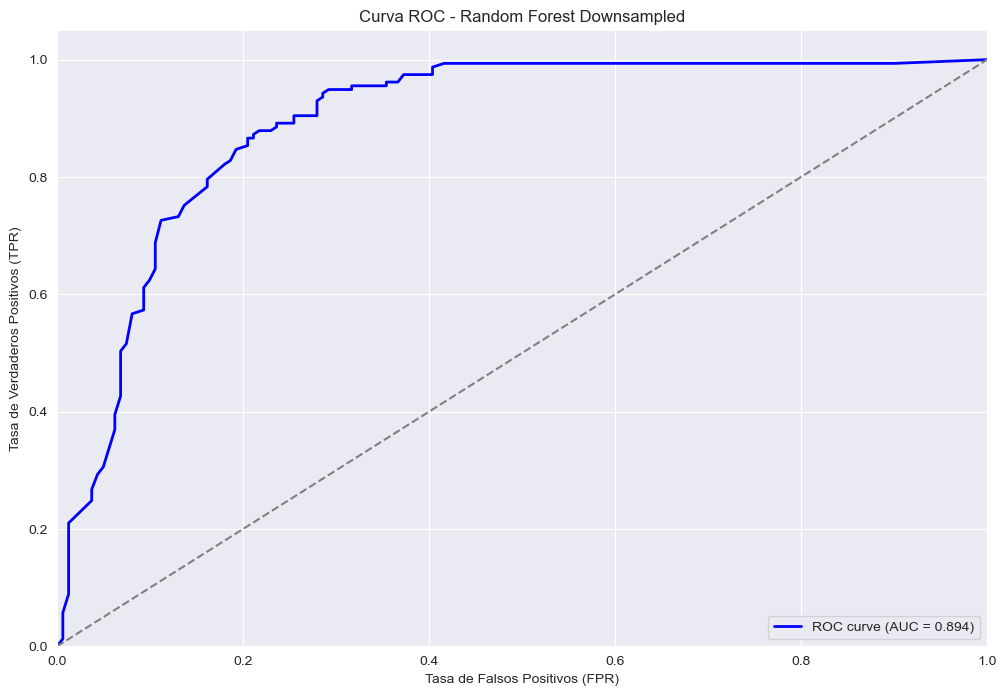

In [103]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = randomForest.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest Downsampled')
plt.legend(loc='lower right')

##### Feature Importance

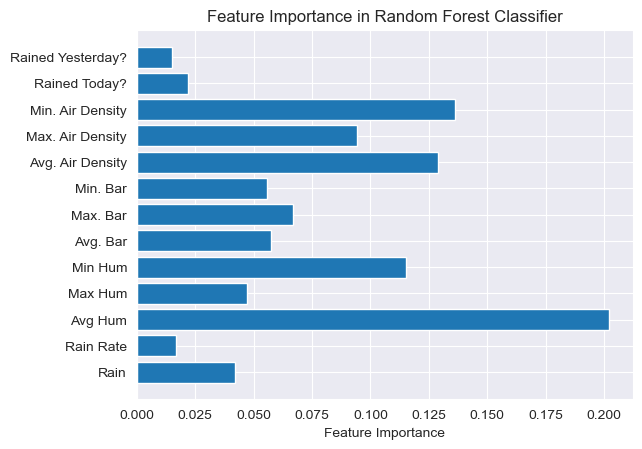

In [104]:
feature_importances = randomForest.feature_importances_
plt.barh(["Rain", "Rain Rate",
          "Avg Hum", "Max Hum", "Min Hum",
          "Avg. Bar", "Max. Bar", "Min. Bar",
          "Avg. Air Density", "Max. Air Density", "Min. Air Density",
          "Rained Today?", "Rained Yesterday?"], feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()

##### Predictions on new data

In [105]:
prediction_input_data = randomForest.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,Yes
7,Yes
8,Yes
9,Yes


In [106]:
y_probs_marzo = randomForest.predict_proba(data_to_predict)[:, 1]
for i in range(0, len(y_probs_marzo)):
    print(f"Probabilidad que llueva mañana, {i+2}/03: {y_probs_marzo[i].round(3)*100:.2f}%")

Probabilidad que llueva mañana, 2/03: 48.00%
Probabilidad que llueva mañana, 3/03: 8.00%
Probabilidad que llueva mañana, 4/03: 30.00%
Probabilidad que llueva mañana, 5/03: 25.00%
Probabilidad que llueva mañana, 6/03: 38.00%
Probabilidad que llueva mañana, 7/03: 45.00%
Probabilidad que llueva mañana, 8/03: 66.00%
Probabilidad que llueva mañana, 9/03: 80.00%
Probabilidad que llueva mañana, 10/03: 82.00%
Probabilidad que llueva mañana, 11/03: 68.00%
Probabilidad que llueva mañana, 12/03: 71.00%
Probabilidad que llueva mañana, 13/03: 72.00%
Probabilidad que llueva mañana, 14/03: 83.00%
Probabilidad que llueva mañana, 15/03: 62.00%
Probabilidad que llueva mañana, 16/03: 55.00%
Probabilidad que llueva mañana, 17/03: 64.00%
Probabilidad que llueva mañana, 18/03: 90.00%
Probabilidad que llueva mañana, 19/03: 68.00%
Probabilidad que llueva mañana, 20/03: 78.00%
Probabilidad que llueva mañana, 21/03: 89.00%
Probabilidad que llueva mañana, 22/03: 84.00%
Probabilidad que llueva mañana, 23/03: 84.0

#### Oversampling the minority

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

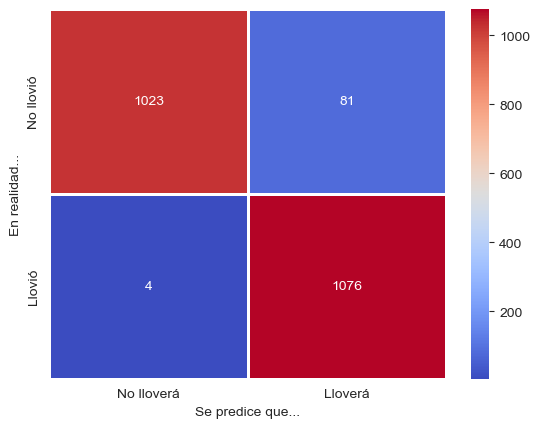

In [107]:
x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, test_size=0.2, random_state=42)

# Model
randomForest2 = RandomForestClassifier(random_state=42)
randomForest2.fit(x_train2, y_train2)
predictions_rf2 = randomForest2.predict(x_test2)

# Confusion Matrix
cm_rf2 = confusion_matrix(y_test2, predictions_rf2)
sns.heatmap(cm_rf2, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [108]:
randomForest2.score(x_test2, y_test2)

0.9610805860805861

In [109]:
print(classification_report(y_test2, predictions_rf2, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9961    0.9266    0.9601      1104
        Rain     0.9300    0.9963    0.9620      1080

    accuracy                         0.9611      2184
   macro avg     0.9630    0.9615    0.9611      2184
weighted avg     0.9634    0.9611    0.9610      2184



In [110]:
scores = cross_val_score(randomForest2, x2, y2, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.9652


##### ROC Curve

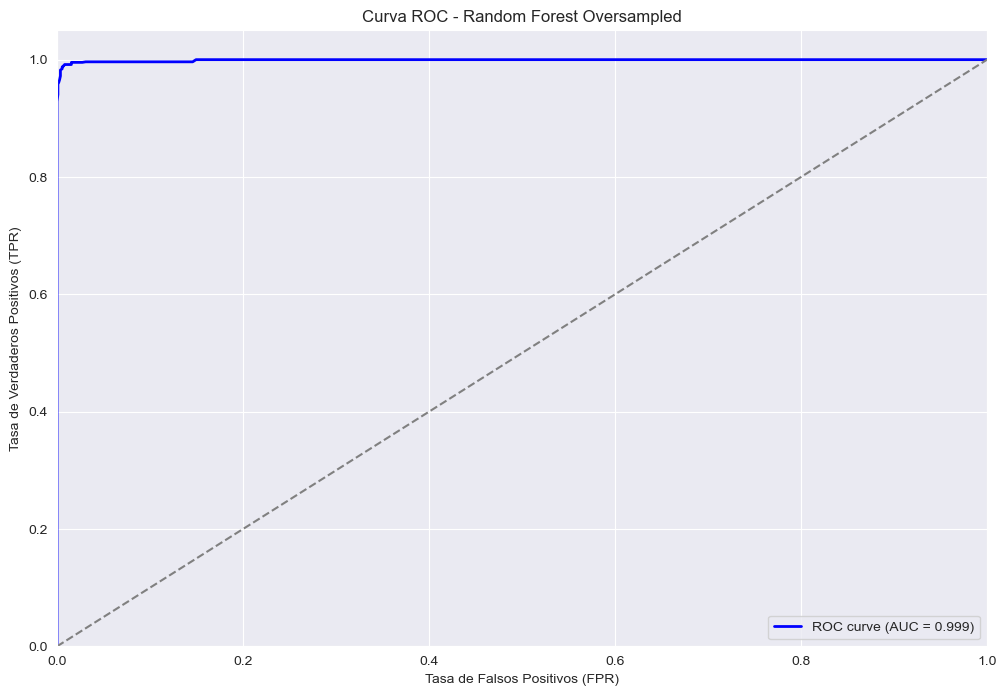

In [111]:
# Obtener probabilidades en vez de predicciones binarias
y_probs2 = randomForest2.predict_proba(x_test2)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr2, tpr2, thresholds2 = roc_curve(y_test2, y_probs2)
roc_auc2 = auc(fpr2, tpr2)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr2, tpr2, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc2:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest Oversampled')
plt.legend(loc='lower right')

##### Predictions on new data

In [112]:
prediction_input_data = randomForest2.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,No
7,Yes
8,No
9,No


#### SMOTE

##### Model creation and fitting

Text(0.5, 25.52222222222222, 'Se predice que...')

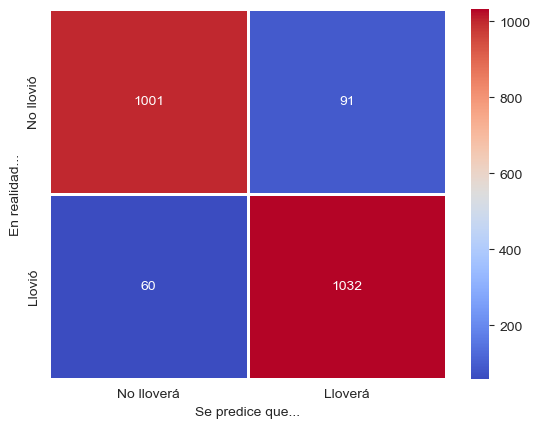

In [113]:
x_train_sm, x_test_sm, y_train_sm, y_test_sm = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

randomForest_sm = RandomForestClassifier(random_state=42)
randomForest_sm.fit(x_train_sm, y_train_sm)
predictions_rf_sm = randomForest_sm.predict(x_test_sm)

# Confusion Matrix
cm_rf_sm = confusion_matrix(y_test_sm, predictions_rf_sm)
sns.heatmap(cm_rf_sm, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

##### Metrics

In [114]:
randomForest_sm.score(x_test_sm, y_test_sm)

0.9308608058608059

In [115]:
print(classification_report(y_test_sm, predictions_rf_sm, target_names=["No Rain", "Rain"], digits=4))

              precision    recall  f1-score   support

     No Rain     0.9434    0.9167    0.9299      1092
        Rain     0.9190    0.9451    0.9318      1092

    accuracy                         0.9309      2184
   macro avg     0.9312    0.9309    0.9308      2184
weighted avg     0.9312    0.9309    0.9308      2184



In [116]:
scores = cross_val_score(randomForest_sm, X_resampled, y_resampled, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

Accuracy promedio: 0.9160


##### ROC Curve

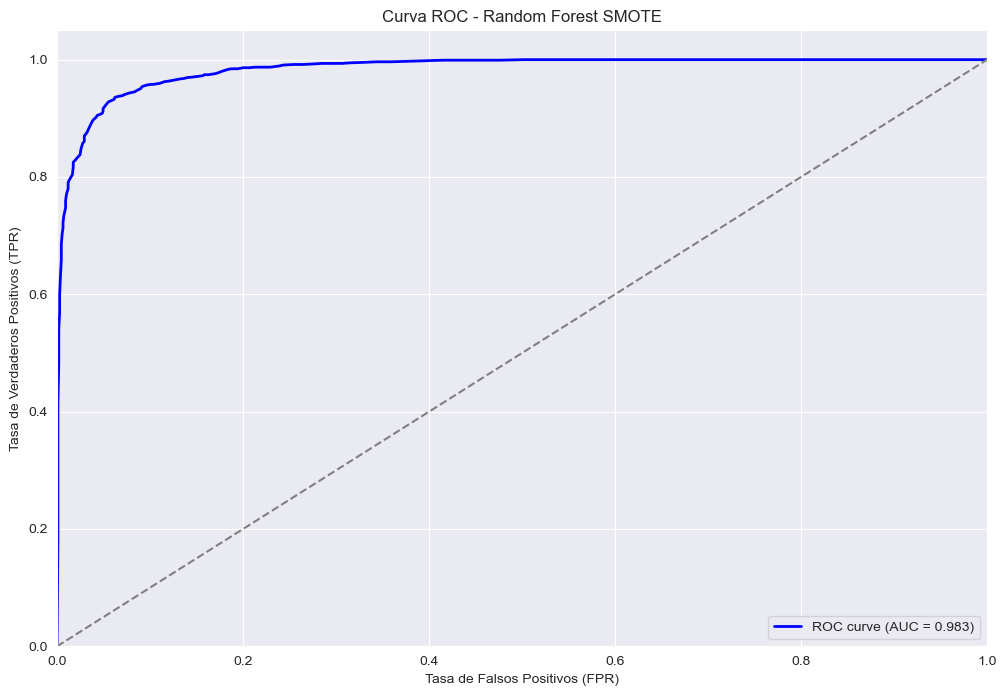

In [117]:
# Obtener probabilidades en vez de predicciones binarias
y_probs_sm = randomForest_sm.predict_proba(x_test_sm)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_sm, y_probs_sm)
roc_auc_sm = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_sm:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest SMOTE')
plt.legend(loc='lower right')

In [118]:
prediction_input_data = randomForest_sm.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

,Rains Tomorrow?
0,No
1,No
2,No
3,No
4,No
5,No
6,Yes
7,Yes
8,No
9,No


#### GridSearchCV for hypertuning

##### RandomForest downsampled

In [ ]:
# ~2m execution time (Ryzen 7 7700X - 8 Cores / 16 Threads)

from sklearn.model_selection import GridSearchCV

rf_grid = RandomForestClassifier(random_state=42)
gr_space = {
    'max_depth': [1,2,3,5,7,10,11,13,15,17,19,20],
    'max_features': [10,20,30,40],
    'min_samples_leaf': [1,2,4],
    'n_estimators': [10,25,50,75,100,200,250,300]
}

grid = GridSearchCV(rf_grid, gr_space, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(x_train, y_train)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

Best hyperparameters are {'max_depth': 10, 'max_features': 10, 'min_samples_leaf': 4, 'n_estimators': 100}

Best score is: 0.8312408577386325

##### RandomForest oversampled

In [ ]:
# ~8m execution time (Ryzen 7 7700X - 8 Cores / 16 Threads)

rf_grid = RandomForestClassifier(random_state=42)
gr_space = {
    'max_depth': [1,2,3,5,7,10,11,13,15,17,19,20],
    'max_features': [10,20,30,40],
    'min_samples_leaf': [1,2,4],
    'n_estimators': [10,25,50,75,100,200,250,300]
}

grid = GridSearchCV(rf_grid, gr_space, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(x_train2, y_train2)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

Best hyperparameters are {'max_depth': 19, 'max_features': 10, 'min_samples_leaf': 1, 'n_estimators': 10}

Best score is: 0.9529420095716368

##### RandomForest SMOTE

In [ ]:
# ~9m30s execution time (Ryzen 7 7700X - 8 Cores / 16 Threads)
rf_grid = RandomForestClassifier(random_state=42)
gr_space = {
    'max_depth': [1,2,3,5,7,10,11,13,15,17,19,20],
    'max_features': [10,20,30,40],
    'min_samples_leaf': [1,2,4],
    'n_estimators': [10,25,50,75,100,200,250,300]
}

grid = GridSearchCV(rf_grid, gr_space, cv=5, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(x_train_sm, y_train_sm)

print('Best hyperparameters are '+str(model_grid.best_params_))
print('Best score is: ' + str(model_grid.best_score_))

Best hyperparameters are {'max_depth': 19, 'max_features': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Best score is: 0.9168768453332863

In [ ]:
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

standarize = StandardScaler()
x_train_scaled = standarize.fit_transform(x_train)
x_test_scaled = standarize.transform(x_test)

# Model
logReg = LogisticRegression(random_state=42, max_iter=2048)
logReg.fit(x_train_scaled, y_train)
predictions = logReg.predict(x_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", linewidths=.75, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"])
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

In [ ]:
logReg.score(x_test_scaled, y_test)

In [ ]:
print(classification_report(y_test, predictions, target_names=["No Rain", "Rain"], digits=4))

In [ ]:
scores = cross_val_score(logReg, X_resampled, y_resampled, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

In [ ]:
# Obtener probabilidades en vez de predicciones binarias
y_probs = logReg.predict_proba(x_test_scaled)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Random Forest SMOTE')
plt.legend(loc='lower right')

In [ ]:
prediction_input_data = logReg.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains Tomorrow?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

## LR (3 days)

In [ ]:
headers_new_model_data_3days = ["Avg Hum", "Max Hum", "Min Hum",
                                "Avg. Bar", "Max. Bar", "Min. Bar",
                                "Avg. Air Density", "Max. Air Density", "Min. Air Density",
                                "Rains in 3 days?"]
model_data_3days = new_data[headers_new_model_data_3days]
model_data_3days

In [ ]:
model_data_3days["Rains in 3 days?"].value_counts()

In [ ]:
x_unb_3days = model_data_3days.drop(columns="Rains in 3 days?")
y_unb_3days = model_data_3days["Rains in 3 days?"]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled3, y_resampled3 = smote.fit_resample(x_unb_3days, y_unb_3days)

x_train, x_test, y_train, y_test = train_test_split(X_resampled3, y_resampled3, test_size=0.2, random_state=42)

# Model
logReg3d = LogisticRegression(max_iter=2048, random_state=42)
logReg3d.fit(x_train, y_train)
predictions= logReg3d.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", linewidths=.65, xticklabels=["No lloverá", "Lloverá"], yticklabels=["No llovió", "Llovió"], )
plt.ylabel("En realidad...")
plt.xlabel("Se predice que...")

In [ ]:
logReg3d.score(x_test, y_test)

In [ ]:
print(classification_report(y_test, predictions, target_names=["No Rain", "Rain"], digits=4))

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(logReg3d, X_resampled3, y_resampled3, cv=5, scoring='accuracy')
print(f"Accuracy promedio: {scores.mean():.4f}")

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Obtener probabilidades en vez de predicciones binarias
y_probs = logReg3d.predict_proba(x_test)[:, 1]  # Probabilidad de clase positiva (lloverá)

# Calcular la Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)  # Área bajo la curva (AUC)

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.show()

In [ ]:
cols_to_use = ["Date","Out Hum","Bar","In Air Density"]
cols_no_date = ["Out Hum","Bar","In Air Density"]

input_data = pd.read_csv("may25.csv", sep=";")[cols_to_use]
input_data["Date"] = pd.to_datetime(input_data["Date"], format="%d-%m-%y")
input_data

In [ ]:
max_hum_input = input_data.groupby("Date")["Out Hum"].max().rename("Max Hum")
min_hum_input = input_data.groupby("Date")["Out Hum"].min().rename("Min Hum")
avg_hum_input = input_data.groupby("Date")["Out Hum"].mean().rename("Avg Hum").round(2)

avg_bar_input = input_data.groupby("Date")["Bar"].mean().rename("Avg. Bar").round(1)
max_bar_input = input_data.groupby("Date")["Bar"].max().rename("Max. Bar").round(1)
min_bar_input = input_data.groupby("Date")["Bar"].min().rename("Min. Bar").round(1)

avg_air_density_input = input_data.groupby("Date")["In Air Density"].mean().rename("Avg. Air Density").round(4)
max_air_density_input = input_data.groupby("Date")["In Air Density"].max().rename("Max. Air Density").round(4)
min_air_density_input = input_data.groupby("Date")["In Air Density"].min().rename("Min. Air Density").round(4)

pre_data_to_predict = pd.concat([avg_hum_input, max_hum_input, min_hum_input, avg_bar_input, max_bar_input, min_bar_input, avg_air_density_input, max_air_density_input, min_air_density_input], axis=1).reset_index()
data_to_predict = pre_data_to_predict.drop(columns=["Date"])
data_to_predict

In [ ]:
prediction_input_data = logReg3d.predict(data_to_predict)
prediction_input_data = pd.DataFrame({"Rains in 3 days?": prediction_input_data}).replace({1: 'Yes', 0: 'No'})
prediction_input_data

In [ ]:
y_probs_lluvia = logReg3d.predict_proba(data_to_predict)[:, 1]
for i in range(0, len(y_probs_lluvia)):
    print(f"Probabilidad que llueva en 3d, 0{i+4}/05: {y_probs_lluvia[i].round(3)*100:.2f}%")